# LAB5

**Disclosure:**

> HAIL `LEVEL 3`: In this Laboratory, I use `ChatGPT` to help me to correct the code, and for complete the code faster, I search for `copilot`.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import label

## Project 1: Edge Detection

read the iamge first.

Image T1:
Shape: (352, 512)
Data type: float64
MAX value: 769.0
MIN value: 0.0

Image T2:
Shape: (352, 512)
Data type: float64
MAX value: 1127.0
MIN value: 0.0


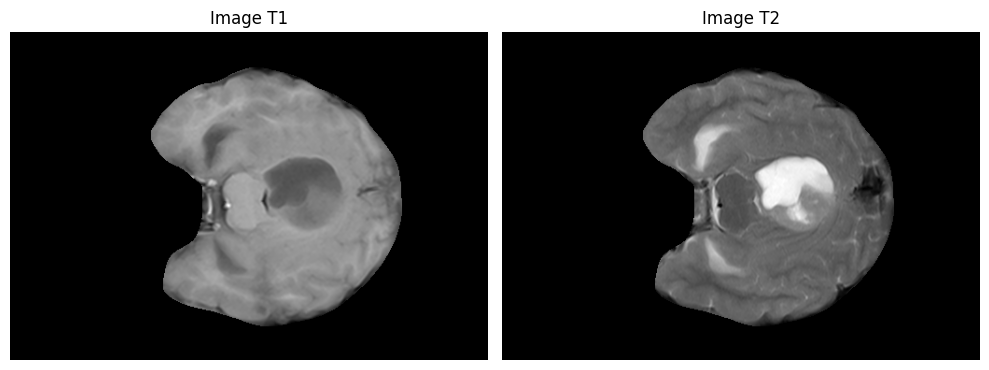

In [2]:
def show_images_L1(images, titles, cmap='gray'):
    """ show images in a row """
    n = len(images)
    plt.figure(figsize=(n * 5, 5))
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, n, i)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# open the iamge lab4-1.npy
img_T1 = np.load('./input/T1.npy')
img_T2 = np.load('./input/T2.npy')

# show the infromation of the image
print("Image T1:")
print("Shape:", img_T1.shape)
print("Data type:", img_T1.dtype)
print("MAX value:", img_T1.max())
print("MIN value:", img_T1.min())

print("\nImage T2:")
print("Shape:", img_T2.shape)
print("Data type:", img_T2.dtype)
print("MAX value:", img_T2.max())
print("MIN value:", img_T2.min())

# show the image
show_images_L1(
    images=[img_T1, img_T2],
    titles=['Image T1', 'Image T2']
)

辅助函数：
1. 实现图像归一化
2. 标记病灶

In [3]:
def normalize(image, dtype: np.dtype = np.uint8):
    return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(dtype)

def markLesion(image, lesion_mask, color=(255, 0, 0)):
    gray_uint8 = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    result_img = cv2.cvtColor(gray_uint8, cv2.COLOR_GRAY2RGB)
    result_img[lesion_mask > 0] = color 
    return result_img

完成实现边界检测的函数和 pipeline

In [4]:
# sobel filter
def filterSobel(image):
    Kx = np.array([[1, 0, -1], 
                   [2, 0, -2],
                   [1, 0, -1]])
    Ky = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]])
    Gx = cv2.filter2D(image.astype(np.float32), -1, Kx)
    Gy = cv2.filter2D(image.astype(np.float32), -1, Ky)
    G = np.sqrt(Gx**2 + Gy**2)
    G = (G / G.max() * 255).astype(np.uint8)
    return G

# get the brain edge
def getBrainEdge(image, threshold: int = 50):
    smooth = cv2.blur(image, (5, 5))
    smooth = cv2.normalize(smooth, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    brain_mask = smooth.copy()
    brain_mask[brain_mask < threshold] = 0
    brain_mask[brain_mask >= threshold] = 255
    
    
    kernel = np.ones((5,5), np.uint8)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_CLOSE, kernel)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, kernel)
    
    G = filterSobel(brain_mask)
    _, brain_edge = cv2.threshold(G, threshold, 255, cv2.THRESH_BINARY)
    
    return brain_edge


def removeBrainEdge(image, edge, kernel: tuple = (79, 79)):
    edge = cv2.blur(edge, kernel)
    mask = image.copy()
    mask[edge > 0] = 0
    return mask


def processLesionSegmentation(image, threshold: int = 100, kernel: tuple = (79, 79)):

    # result
    result = {
        "images": [],
        "titles": []
    }
    result["images"].append(image)
    result["titles"].append("Original Image")

    # brain edge
    image_brain_edge = getBrainEdge(image, threshold=50)
    kernel_dilate_operation = np.ones((3, 3), np.uint8)
    image_brain_edge = cv2.dilate(image_brain_edge, kernel_dilate_operation, iterations=1)
    result["images"].append(image_brain_edge)
    result["titles"].append("Brain Edge")

    # smooth filter
    image_smooth = cv2.blur(image, (5, 5))
    result["images"].append(image_smooth)
    result["titles"].append("Smoothed Image")

    # Sobel filter
    G = filterSobel(image_smooth)
    result["images"].append(G)
    result["titles"].append("After Sobel Filter")

    # threshold T
    _, image_edge = cv2.threshold(G, threshold, 255, cv2.THRESH_BINARY)
    result["images"].append(image_edge)
    result["titles"].append(f"Edge Image: Threshold = {threshold}")

    # remove brain edge from the edge image
    image_no_brain_edge = removeBrainEdge(image_edge, image_brain_edge, kernel=kernel)
    # perform morphological operations: open
    kernel_open_operation = np.ones((3, 3), np.uint8)
    image_opened = cv2.morphologyEx(image_no_brain_edge, cv2.MORPH_OPEN, kernel_open_operation)
    # perform morphological operations: close
    kernel_close_operation = np.ones((5, 5), np.uint8)
    image_closed = cv2.morphologyEx(image_opened, cv2.MORPH_CLOSE, kernel_close_operation)


    # connected component analysis
    image_labeled, num_features = label(image_closed)
    if num_features == 0:
        image_lesion = image_closed
    else:
        max_label = 1 + np.argmax([np.sum(image_labeled==i) for i in range(1, num_features+1)])
        image_lesion = np.zeros_like(image_closed)
        image_lesion[image_labeled == max_label] = 255
    result["images"].append(image_lesion)
    result["titles"].append("Lesion Image")

    # mark the lesion on the original image
    image_marked = markLesion(image, image_lesion)
    result["images"].append(image_marked)
    result["titles"].append("Image with Lesion Marked")

    return result

### 1.1 Implement the Sobel gradient kernel and get a binary mask with a specified threshold T.


========== T1 edge images generated ==========


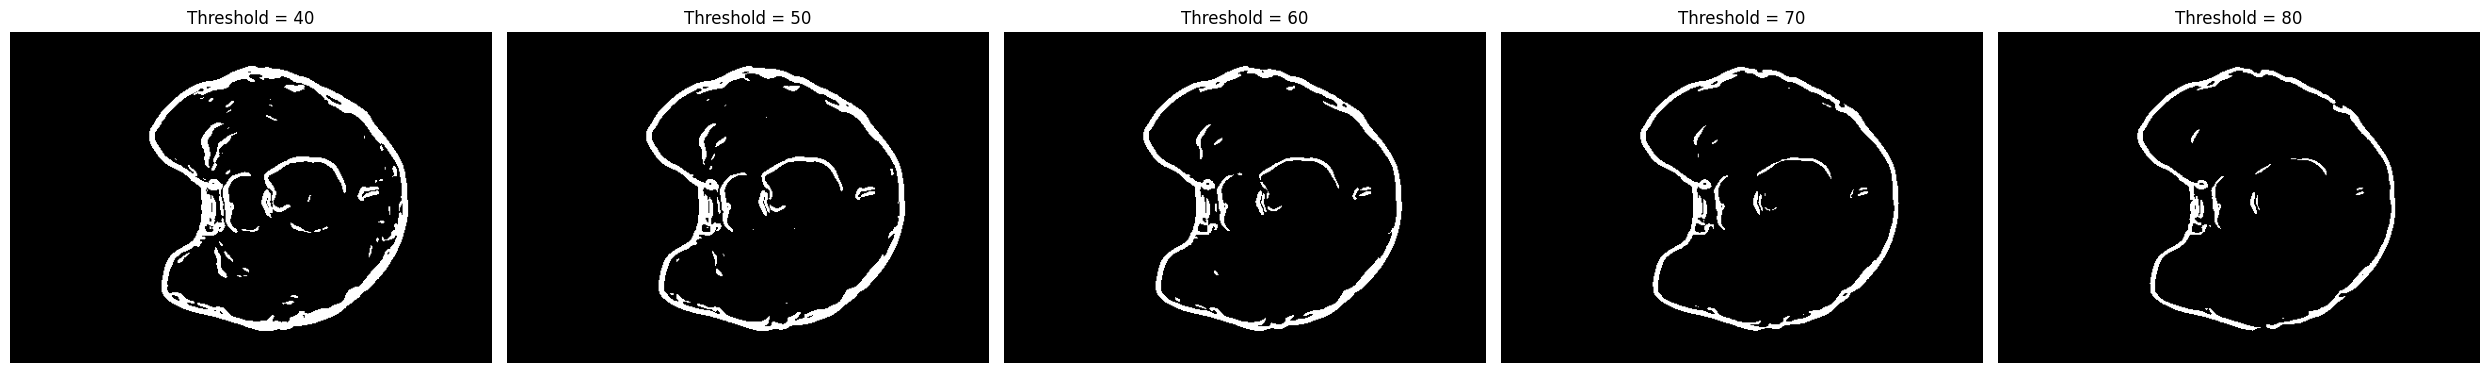

========== T2 edge images generated ==========


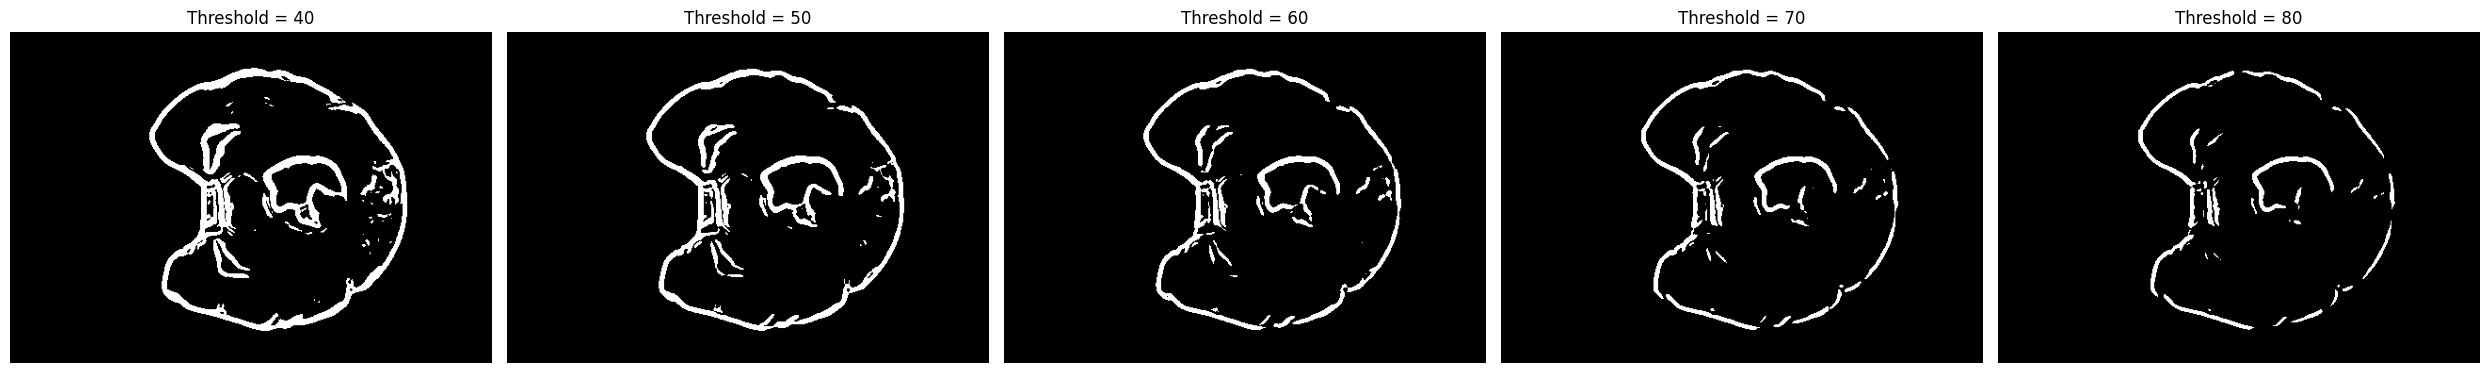

In [5]:
def getLesionEdge(image, threshold: int = 50):
    smooth = cv2.blur(image, (5, 5))
    smooth = cv2.normalize(smooth, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    G = filterSobel(smooth)
    _, brain_edge = cv2.threshold(G, threshold, 255, cv2.THRESH_BINARY)
    return brain_edge

img_T1 = np.load('./input/T1.npy')
img_T2 = np.load('./input/T2.npy')

# process the T1 image
threshold_T1_list = [40, 50, 60, 70, 80]
edge_images_T1 = []
for threshold in threshold_T1_list:
    edge = getLesionEdge(img_T1, threshold)
    edge_images_T1.append(edge)

print("========== T1 edge images generated ==========")
show_images_L1(
    images=edge_images_T1,
    titles=[f"Threshold = {t}" for t in threshold_T1_list]
)

# process the T2 image
threshold_T2_list = [40, 50, 60, 70, 80]
edge_images_T2 = []
for threshold in threshold_T2_list:
    edge = getLesionEdge(img_T2, threshold)
    edge_images_T2.append(edge)

print("========== T2 edge images generated ==========")
show_images_L1(
    images=edge_images_T2,
    titles=[f"Threshold = {t}" for t in threshold_T2_list]
)


### 1.2 Segment the lesion

========== Results for T1 Image ==========



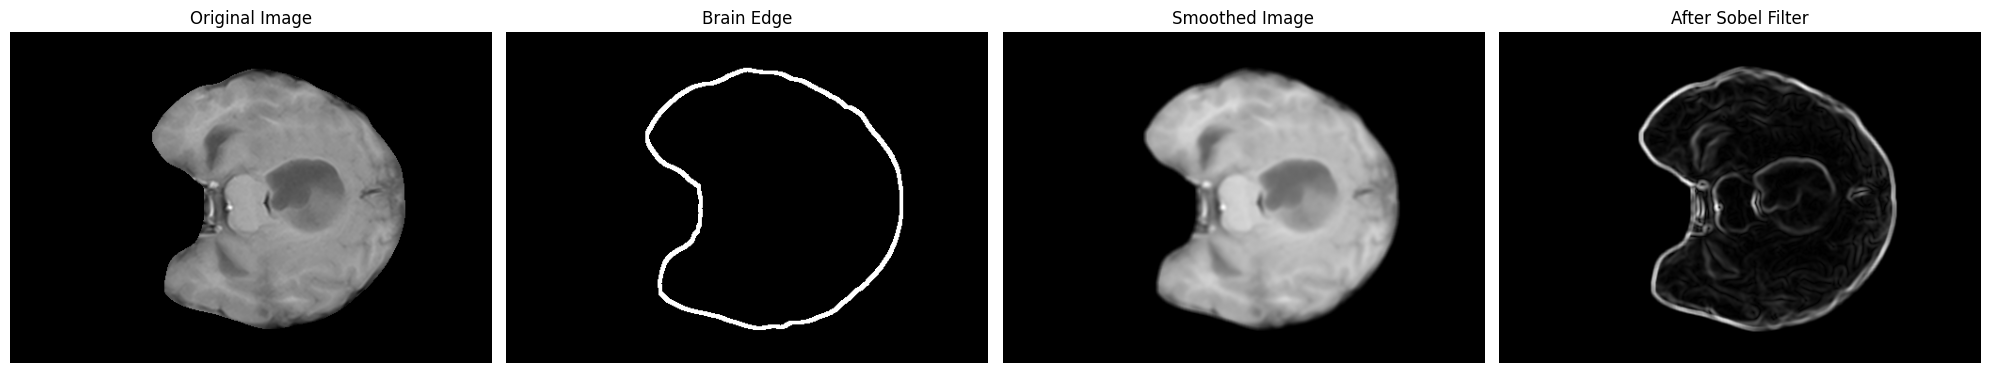

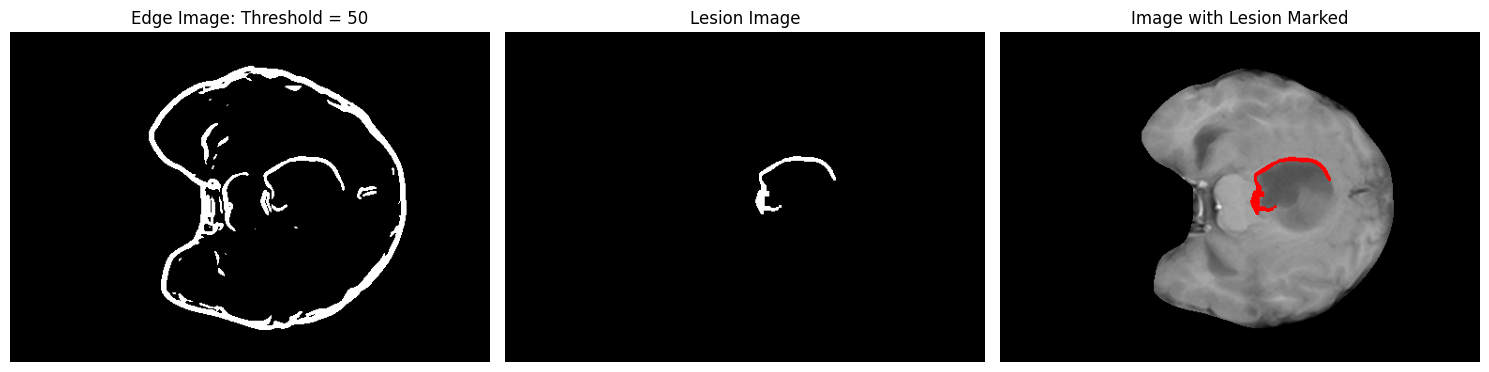

========== Results for T2 Image ==========



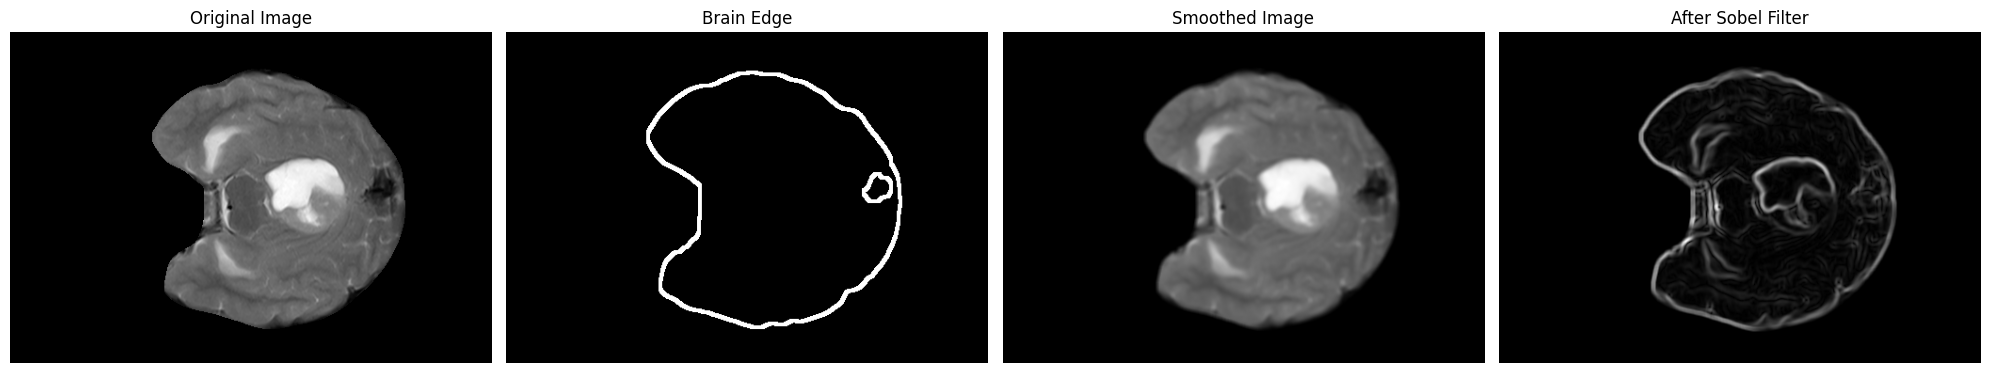

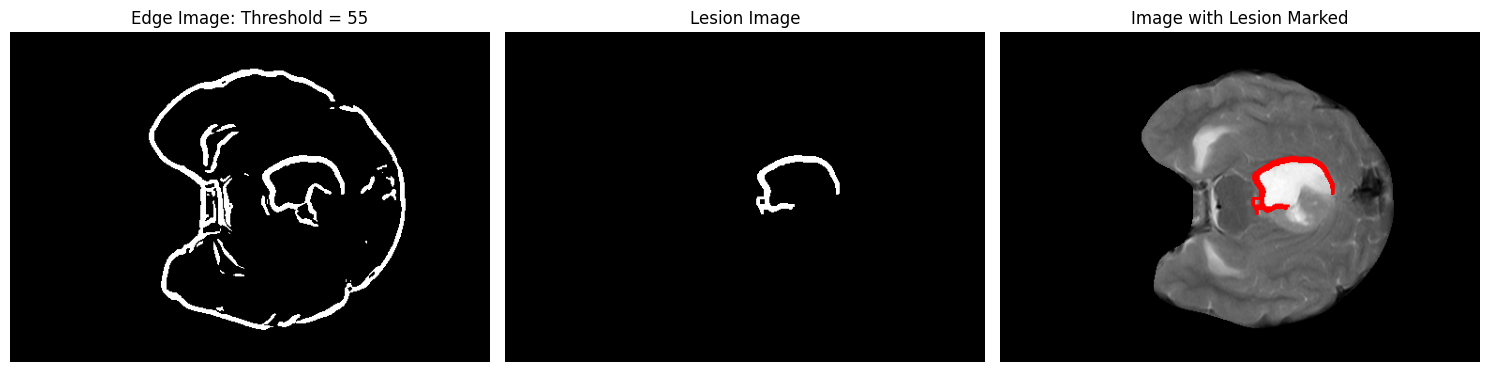

In [6]:
# test
threshold_T1 = 50
kernel_T1 = (7, 7)
threshold_T2 = 55
kernel_T2 = (5, 5)

result_T1 = processLesionSegmentation(img_T1, threshold=threshold_T1, kernel=kernel_T1)
result_T2 = processLesionSegmentation(img_T2, threshold=threshold_T2, kernel=kernel_T2)

print("========== Results for T1 Image ==========\n")
show_images_L1(
    images=result_T1["images"][0:4],
    titles=result_T1["titles"][0:4]
)
show_images_L1(
    images=result_T1["images"][4:7],
    titles=result_T1["titles"][4:7]
)

print("========== Results for T2 Image ==========\n")
show_images_L1(
    images=result_T2["images"][0:4],
    titles=result_T2["titles"][0:4]
)
show_images_L1(
    images=result_T2["images"][4:7],
    titles=result_T2["titles"][4:7]
)

### 1.3 Discuss: Compare the effects of the 2 modes


由于我们的 pipeline 主要是通过阈值 T 来判断病灶的，因此 T 的选择对结果非常重要。而 T1 和 T2 两种模式中，病灶的亮度明显不同， T1 中病灶的亮度较暗，而 T2 中病灶的亮度较亮。因此，这里的边缘检测算法对 T1 和 T2 的检测结果明显不同。

- T1 的阈值必须卡的很好，一旦高了就容易让病灶的边缘消失，但是阈值太低又容易导致周边的噪声特别多（虽然这个问题可以通过保留最大连通域得到优化）。
- T2 的病灶亮度明显高于周围的正常组织，因此 T2 的阈值范围比较宽松，并且得到的病灶的边缘也很粗，可以很容易用形态学和连通域的方式寻找到合适、美观的病灶边缘。

## Project 2: Thresholding

### 2.1 Implement Iterative global threshold segmentation

辅助函数：显示当前图像的直方图并展示。

In [7]:
def quantify_histogram(img, dtype: np.dtype = np.uint8):
    """
    quantify the image according to the histogram
    """

    # change the image to dtype
    img = img.astype(dtype)
    image_min = img.min()
    image_max = img.max()

    if image_max == image_min:
        output_image = np.zeros(256, dtype=dtype)
        output_image[0] = 1.0
        return output_image

    # normalize the image
    image_norm = normalize(img, dtype=dtype)
    image_quantized = np.clip((image_norm * 255).astype(np.int32), 0, 255)

    output_image = np.bincount(image_quantized.ravel(), minlength=256).astype(np.float32)
    output_image = output_image / output_image.sum()
    return output_image

def show_images_histogram(images, titles, figsize=(15, 5), cmap='gray'):
    """ show images in a row """
    fig, axes = plt.subplots(2, len(images), figsize=(5 * len(images), 10))
    bins = np.arange(256)
    for i, (img, title) in enumerate(zip(images, titles)):
        # first row: images
        axes[0, i].imshow(normalize(img), cmap=cmap)
        axes[0, i].set_title(title)
        axes[0, i].axis('off')

        # second row: histograms
        images_hist = quantify_histogram(img)
        axes[1, i].bar(bins, images_hist, width=2.0)
        axes[1, i].set_title(f'{title} Histogram')
        axes[1, i].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()

编写全局阈值迭代函数

In [8]:
def thresholdIterative(image, T_init: int = 100, tolerance: int = 1, max_iterations: int = 100, dtype: np.dtype = np.uint8):
    T = T_init
    image = normalize(image, dtype=dtype)
    signal_mask = (image > 0)
    for i in range(max_iterations):
        signal = image[signal_mask]
        lower = signal[signal <= T]
        upper = signal[signal > T]
        if len(lower) == 0 or len(upper) == 0:
            break
        T_new = (lower.mean() + upper.mean()) / 2
        if abs(T - T_new) < tolerance:
            break
        T = T_new
    mask = np.zeros_like(image, dtype=dtype)
    mask[image > T] = 255
    return mask, T

Iterative Threshold for T1: 116.28879911470014


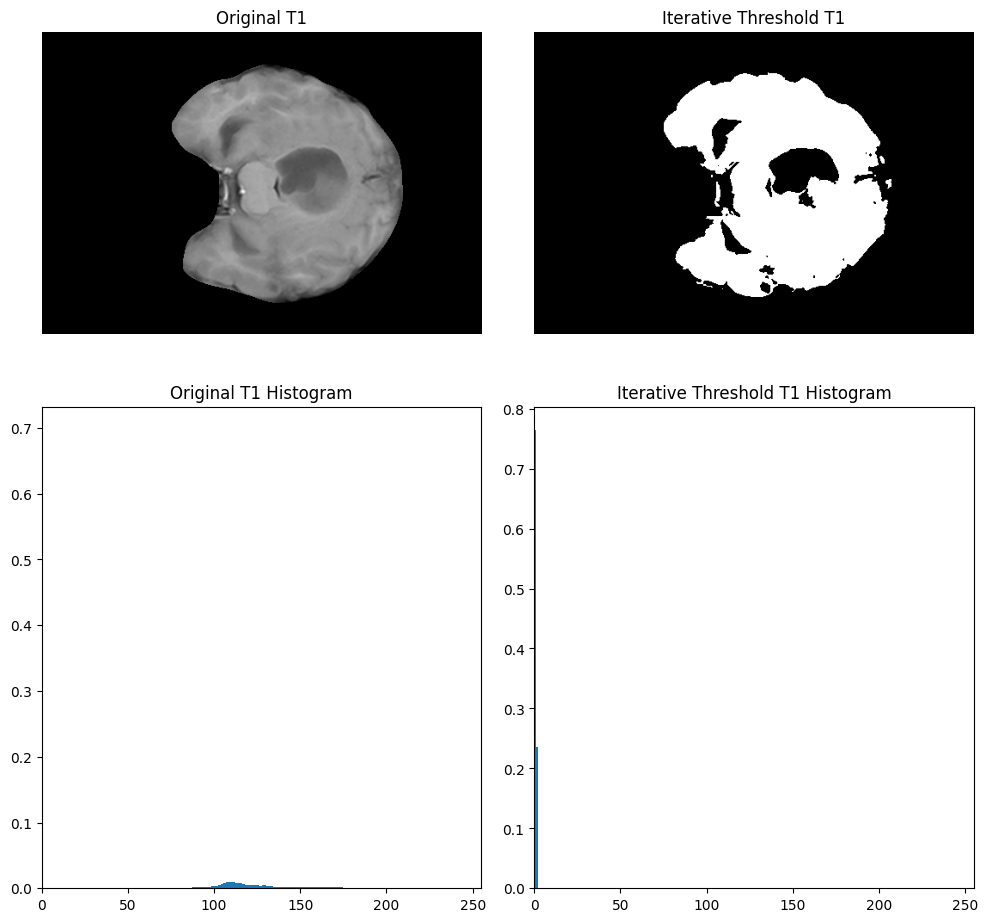

Iterative Threshold for T2: 151.3743447774998


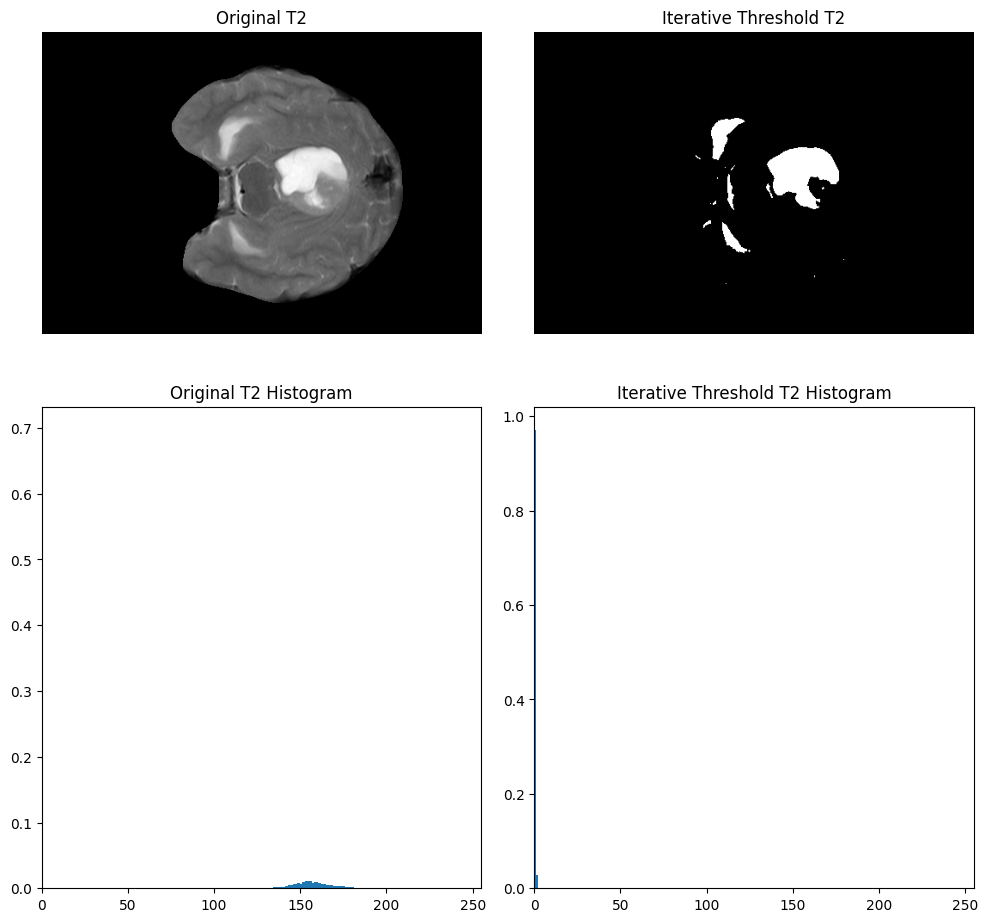

In [9]:
# test
img_T1_normalized = normalize(img_T1)
img_T2_normalized = normalize(img_T2)

T_init = 100
tolerance = 1
max_iterations = 100
mask_T1_iter, T1_iter = thresholdIterative(img_T1, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)
mask_T2_iter, T2_iter = thresholdIterative(img_T2, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)

print(f"Iterative Threshold for T1: {T1_iter}")
show_images_histogram(
    images=[img_T1_normalized, mask_T1_iter],
    titles=["Original T1", "Iterative Threshold T1"]
)

print(f"Iterative Threshold for T2: {T2_iter}")
show_images_histogram(
    images=[img_T2_normalized, mask_T2_iter],
    titles=["Original T2", "Iterative Threshold T2"]
)

尝试不同的初始阈值 `T_init`

========== Iterative Thresholds for T1 Image ==========

Iterative Threshold for T1 with initial T=20: 117.67
Iterative Threshold for T1 with initial T=50: 117.67
Iterative Threshold for T1 with initial T=100: 117.67
Iterative Threshold for T1 with initial T=150: 118.12
Iterative Threshold for T1 with initial T=200: 118.12


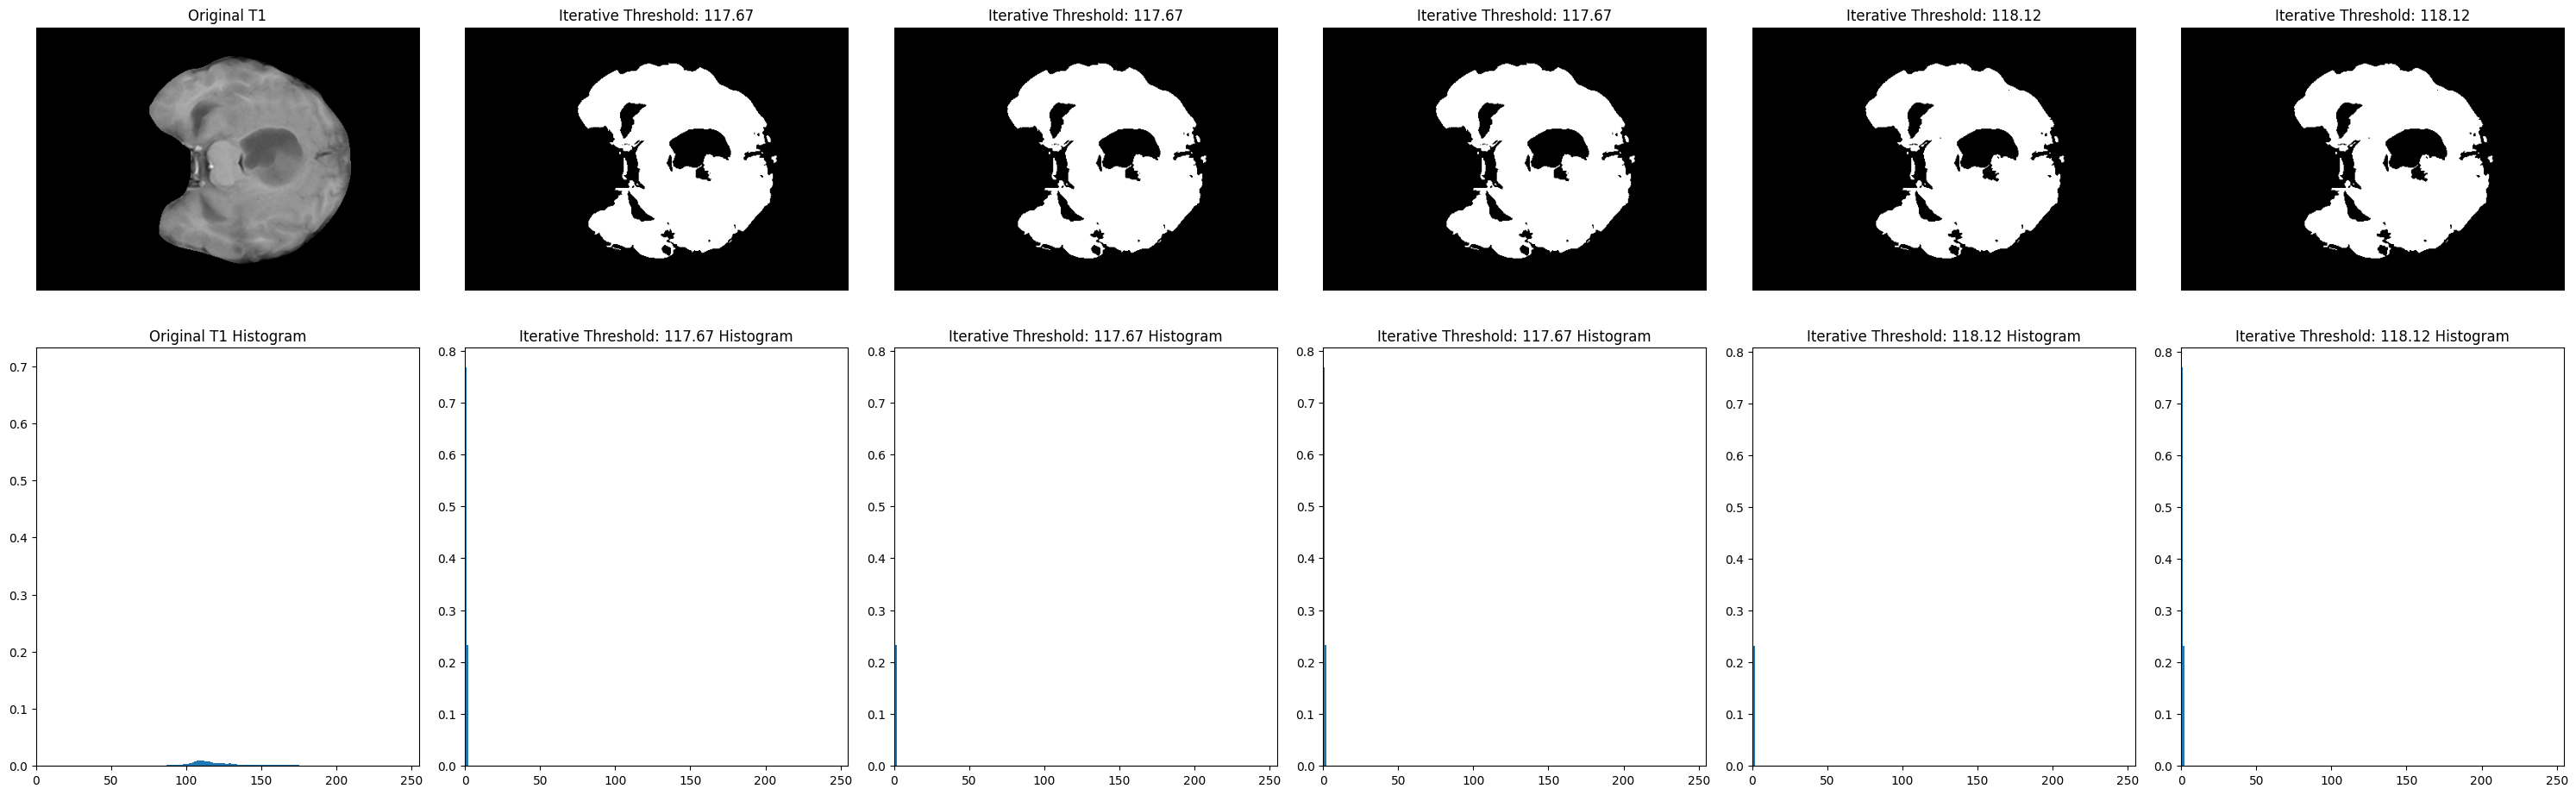

========== Iterative Thresholds for T2 Image ==========

Iterative Threshold for T2 with initial T=20: 152.39
Iterative Threshold for T2 with initial T=50: 152.39
Iterative Threshold for T2 with initial T=100: 152.39
Iterative Threshold for T2 with initial T=150: 152.39
Iterative Threshold for T2 with initial T=200: 152.39


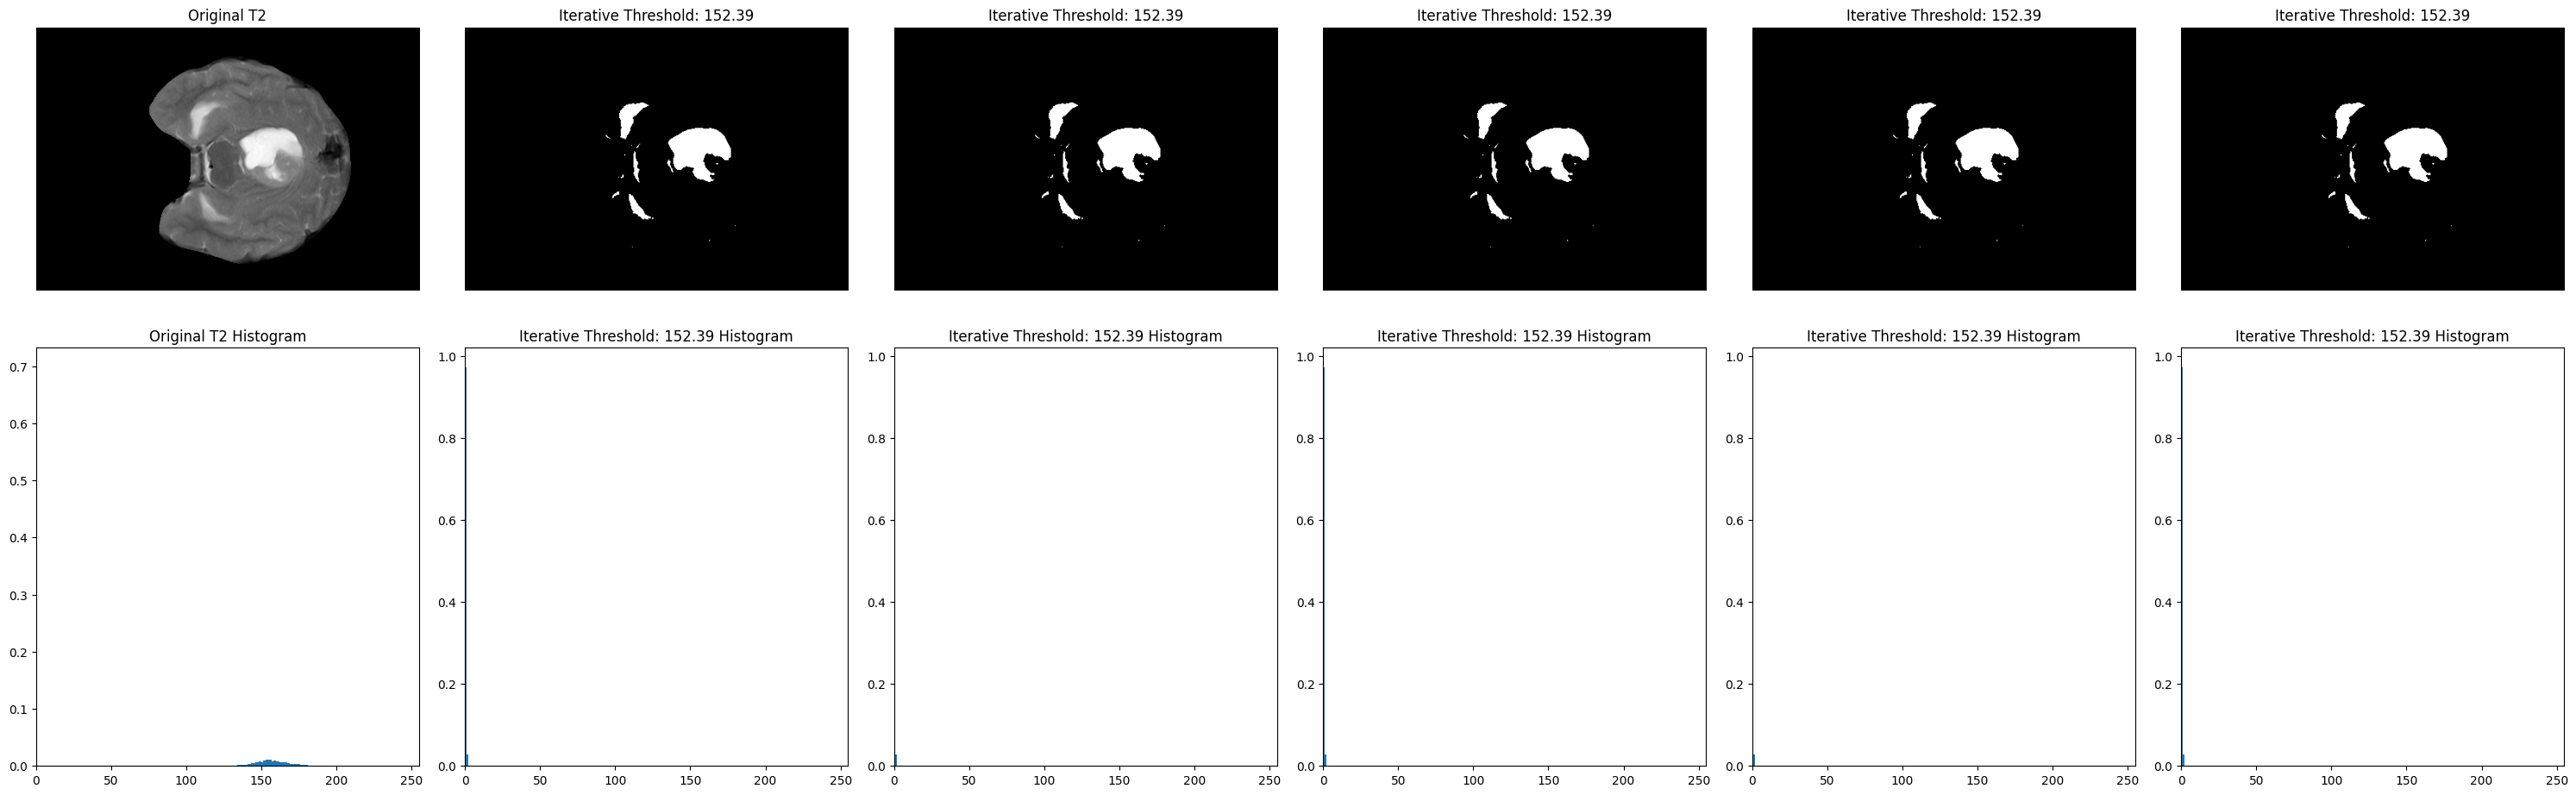

In [10]:
tolerance = 0
max_iterations = 100
T_init_list = [20, 50, 100, 150, 200]
result_T1 = {
    "images": [img_T1_normalized],
    "threshold": [],
    "titles": ["Original T1"]
}
result_T2 = {
    "images": [img_T2_normalized],
    "threshold": [],
    "titles": ["Original T2"]
}

# Apply iterative thresholding for each initial threshold
for T in T_init_list:
    mask, threshold = thresholdIterative(img_T1, T_init=T, tolerance=tolerance, max_iterations=max_iterations)
    result_T1["images"].append(mask)
    result_T1["threshold"].append(threshold)
    result_T1["titles"].append(f"Iterative Threshold: {threshold:.2f}")

    mask, threshold = thresholdIterative(img_T2, T_init=T, tolerance=tolerance, max_iterations=max_iterations)
    result_T2["images"].append(mask)
    result_T2["threshold"].append(threshold)
    result_T2["titles"].append(f"Iterative Threshold: {threshold:.2f}")

# print the thresholds
print("========== Iterative Thresholds for T1 Image ==========\n")
for i in range(len(T_init_list)):
    print(f"Iterative Threshold for T1 with initial T={T_init_list[i]}: {result_T1['threshold'][i]:.2f}")

# Display the results
show_images_histogram(
    images=result_T1["images"],
    titles=result_T1["titles"]
)

print("========== Iterative Thresholds for T2 Image ==========\n")
for i in range(len(T_init_list)):
    print(f"Iterative Threshold for T2 with initial T={T_init_list[i]}: {result_T2['threshold'][i]:.2f}")

show_images_histogram(
    images=result_T2["images"],
    titles=result_T2["titles"]
)

从 T1 和 T2 的结果来看，在 `max_iterations` 较大时，迭代次数较大。此时，选取不同的 `T_init` 对结果没有什么影响，阈值都能收敛到一个较为合理的值。

但是，如果 `max_iterations` 较小（例如上面选取了迭代次数为 1 ）时，不同的 `T_init` 就会对结果有很大影响。

### 2.2 Implement Otsu's optimum thresholding algorithm to segment the lesion

Otsu Threshold for T1: 117


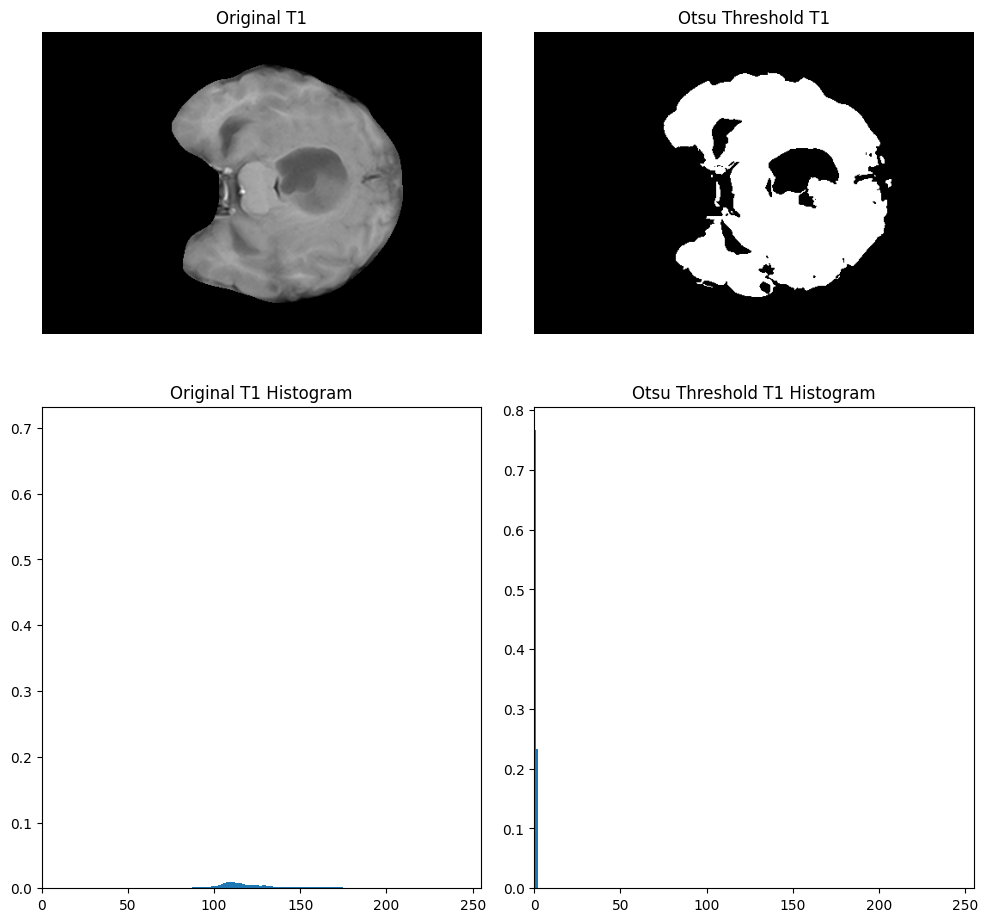

Otsu Threshold for T2: 152


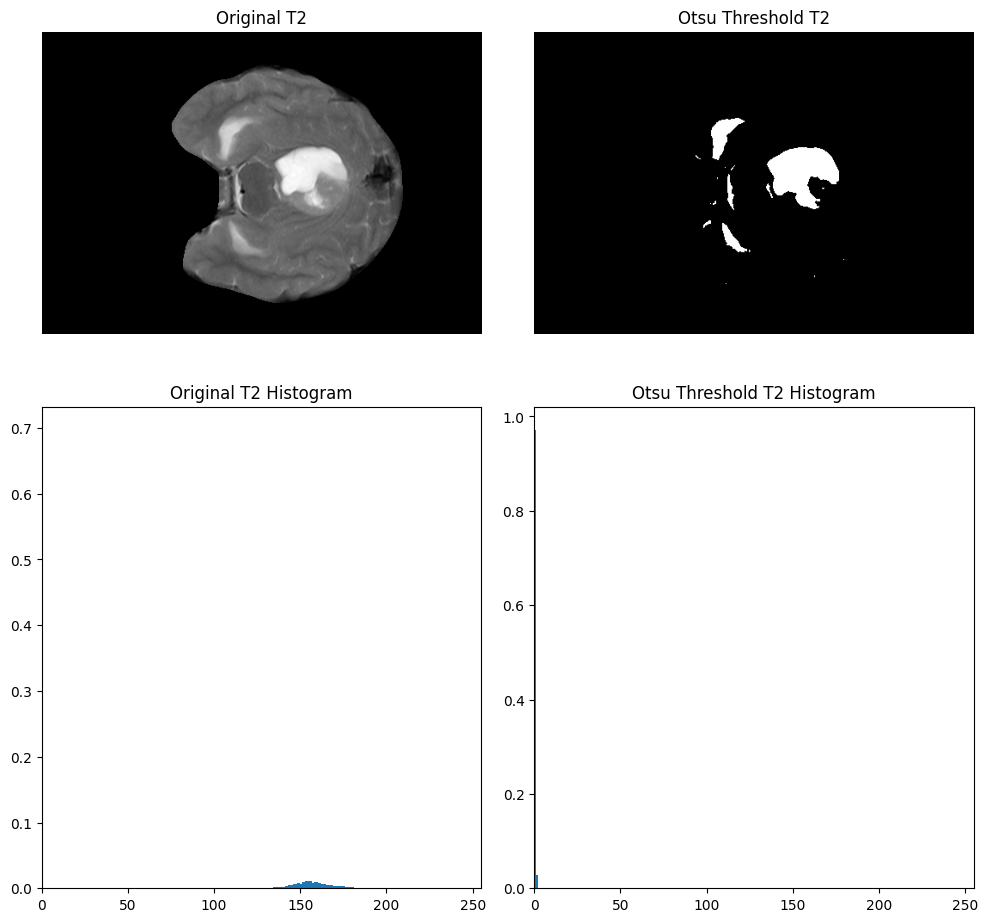

In [11]:
def thresholdOtsu(image, dtyle: np.dtype = np.uint8):

    # normalize the image
    image = normalize(image, dtype=dtyle)
    signal_mask = (image > 0)
    signal = image[signal_mask]

    # calculate the histogram
    hist, _ = np.histogram(signal, bins=256, range=(0,256))
    hist = hist / hist.sum()
    total_mean = np.sum(np.arange(256) * hist)

    # init parameters
    max_var = -1
    best_t = 0
    w0 = 0
    sum0 = 0

    # iterate through all possible thresholds
    for t in range(256):
        w0 += hist[t]
        if w0 == 0 or w0 == 1:
            continue
        sum0 += t * hist[t]
        mean0 = sum0 / w0
        w1 = 1 - w0
        sum1 = total_mean - sum0
        mean1 = sum1 / w1
        var_between = w0 * w1 * (mean0 - mean1) ** 2
        if var_between > max_var:
            max_var = var_between
            best_t = t
    mask = np.zeros_like(image, dtype=np.uint8)
    mask[image > best_t] = 255
    return mask, best_t


mask_T1_otsu, T1_otsu = thresholdOtsu(img_T1)
mask_T2_otsu, T2_otsu = thresholdOtsu(img_T2)

print(f"Otsu Threshold for T1: {T1_otsu}")
show_images_histogram(
    images=[img_T1_normalized, mask_T1_otsu],
    titles=["Original T1", "Otsu Threshold T1"]
)

print(f"Otsu Threshold for T2: {T2_otsu}")
show_images_histogram(
    images=[img_T2_normalized, mask_T2_otsu],
    titles=["Original T2", "Otsu Threshold T2"]
)

### 2.3 Compare the results

Iterative Threshold for T1: 116.28879911470014
Otsu Threshold for T1: 117

Iterative Threshold for T2: 151.3743447774998
Otsu Threshold for T2: 152


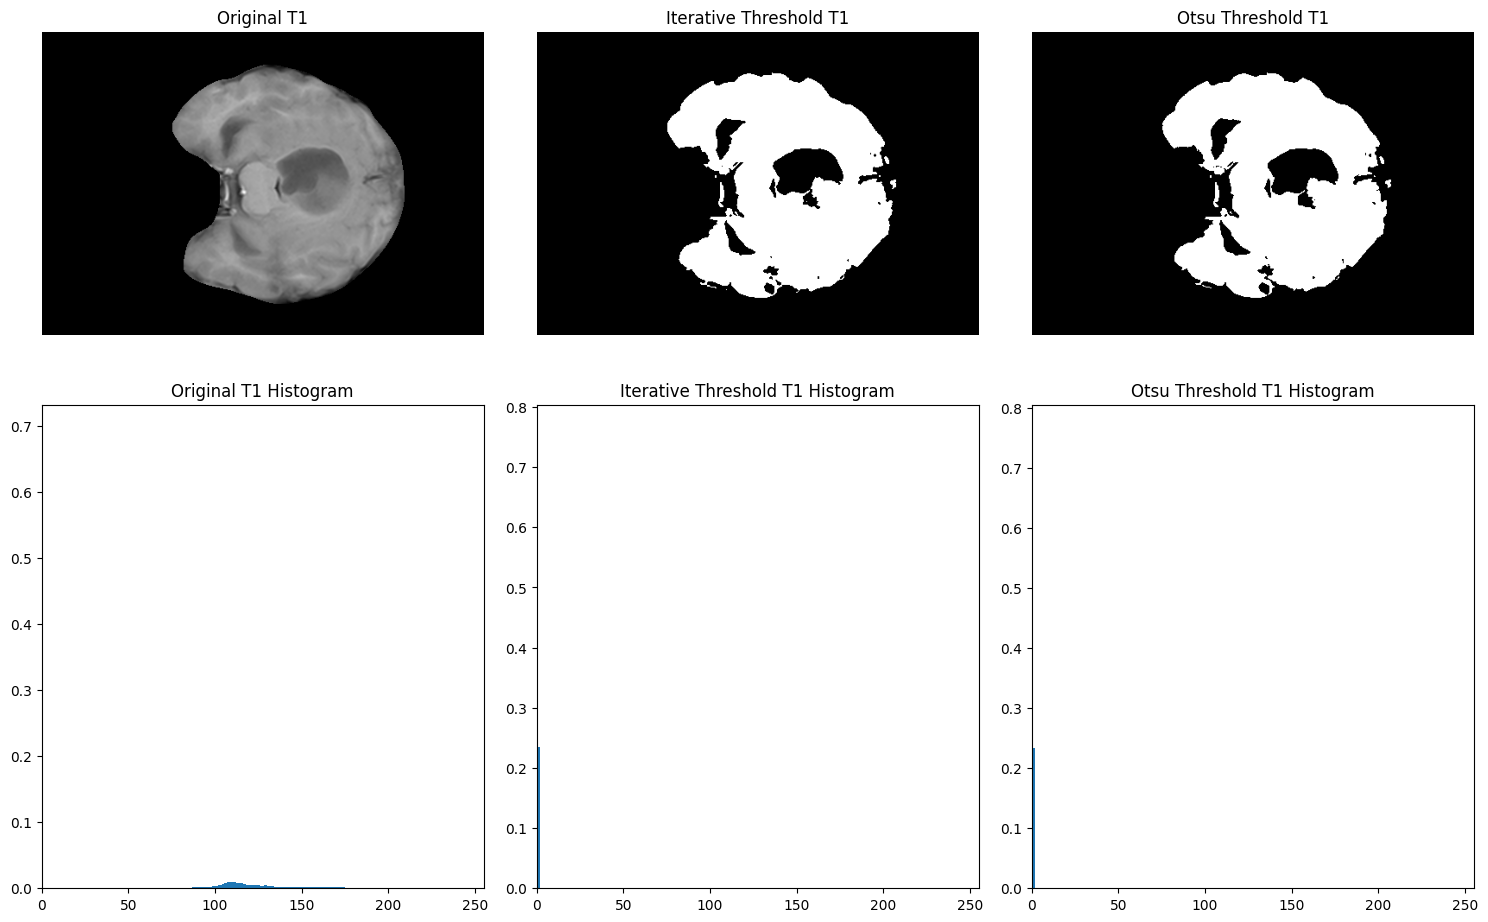

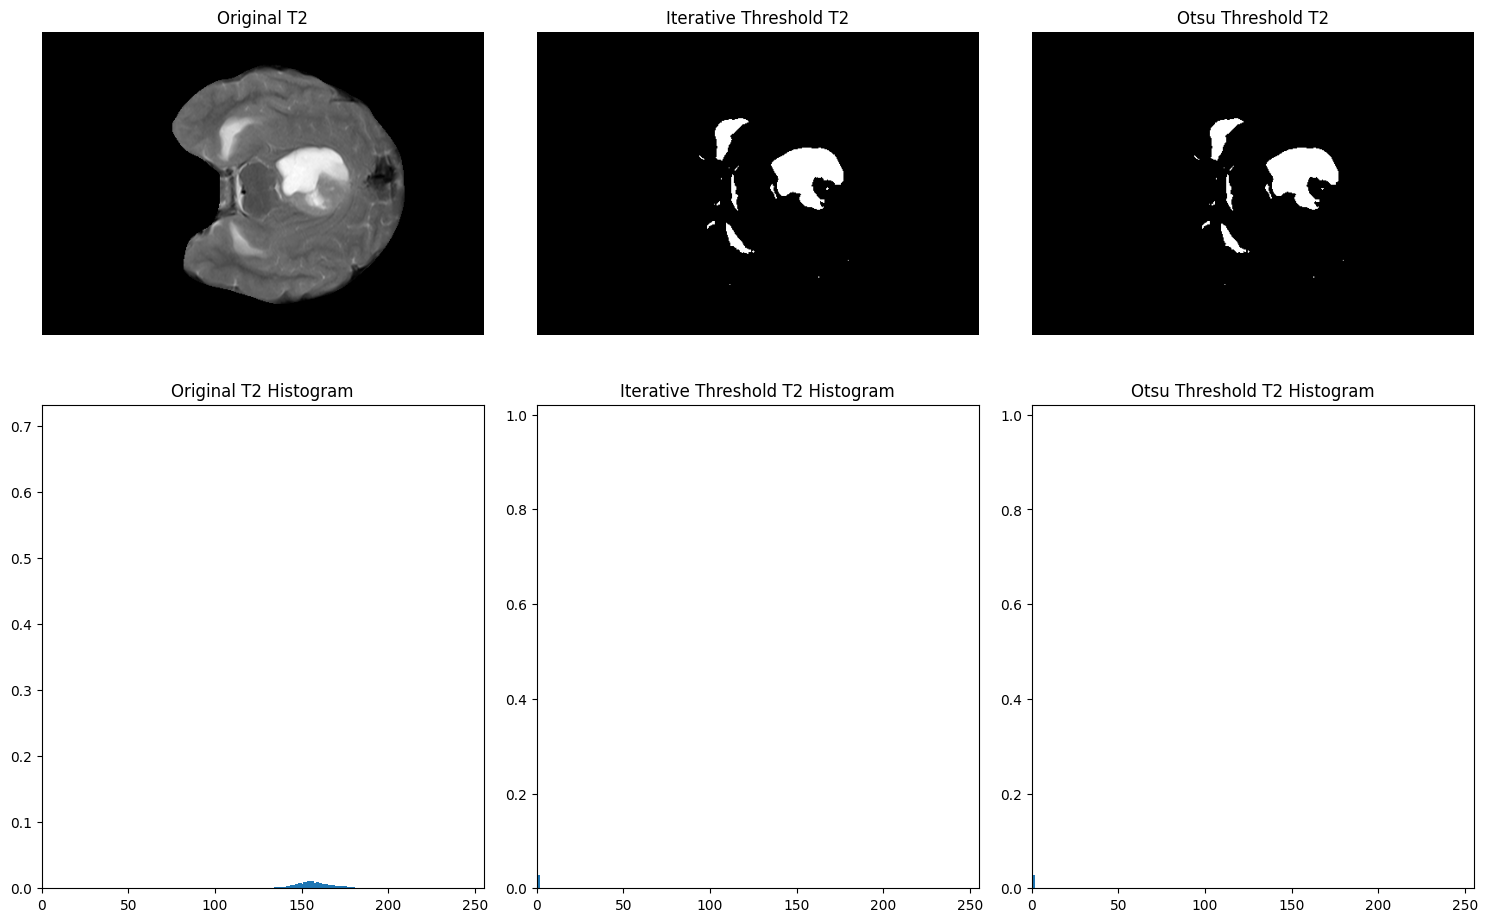

In [12]:
# iterative
T_init = 100
tolerance = 1
max_iterations = 100
mask_T1_iter, T1_iter = thresholdIterative(img_T1, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)
mask_T2_iter, T2_iter = thresholdIterative(img_T2, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)

# otsu
mask_T1_otsu, T1_otsu = thresholdOtsu(img_T1)
mask_T2_otsu, T2_otsu = thresholdOtsu(img_T2)

# print the thresholds
print(f"Iterative Threshold for T1: {T1_iter}")
print(f"Otsu Threshold for T1: {T1_otsu}")
print()
print(f"Iterative Threshold for T2: {T2_iter}")
print(f"Otsu Threshold for T2: {T2_otsu}")

# show the images
show_images_histogram(
    images=[img_T1_normalized, mask_T1_iter, mask_T1_otsu],
    titles=["Original T1", "Iterative Threshold T1", "Otsu Threshold T1"]
)

show_images_histogram(
    images=[img_T2_normalized, mask_T2_iter, mask_T2_otsu],
    titles=["Original T2", "Iterative Threshold T2", "Otsu Threshold T2"]
)

以上两种阈值分类方法的结果非常相近，用肉眼根本区分不出差异。但是从方法的原理出发还是有一点区别的，比如： Otsu 方法的复杂度与精度强相关，想要增大阈值的精度会使得算法复杂度大大提高（上面我的代码中精度为个位，因此最后计算出的阈值是整数）；而迭代法的复杂度则与迭代数量强相关，如果 `T_init` 定义的不好，需要很大的迭代数，导致非常耗时。

## Project 3: Segmentation

先写一些辅助函数：
- 添加不同颜色的 mask
- 计算病灶区域的面积（因为处理的都是二维图像，所以只需要面积就行）

In [13]:
def addMask(image, mask, color: tuple = (255, 0, 0), dtype: np.dtype = np.uint8):
    image_rgb = cv2.cvtColor(normalize(image, dtype=dtype), cv2.COLOR_GRAY2RGB)
    image_rgb[mask > 0] = color
    return image_rgb

def computeLesionVolume2D(mask, pixel_size: tuple = (1, 1)):
    lesion_pixels = np.sum(mask > 0)
    area_per_pixel = pixel_size[0] * pixel_size[1]
    area = lesion_pixels * area_per_pixel
    return area

#### 3.1.1 Region Growing



Lesion Area from Region Growing: 3142 mm^2


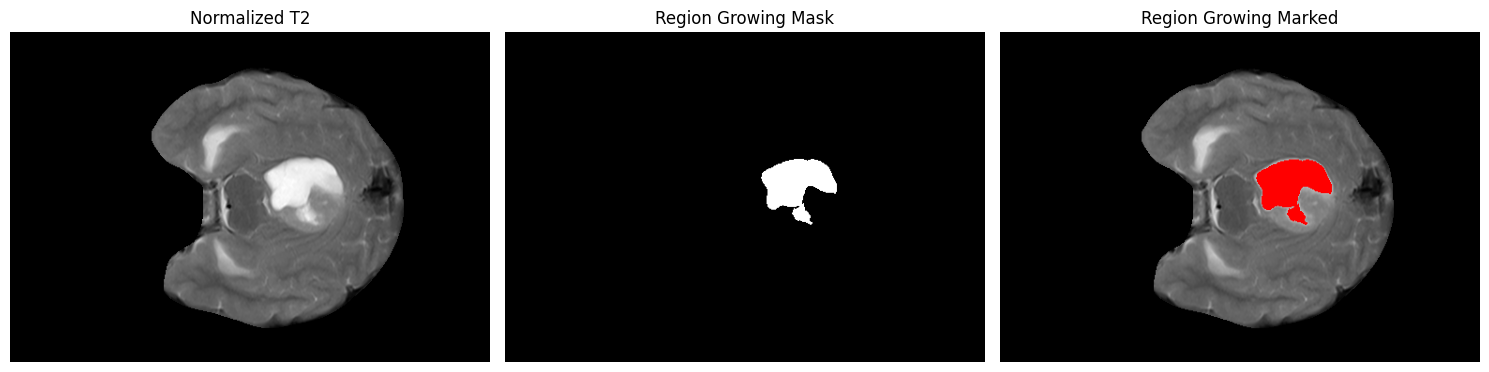

In [14]:
from skimage.morphology import flood

def regionGrowing(image, seed, tolerance: int = 10, dtype: np.dtype = np.uint8):
    # normalize
    image = normalize(image, dtype=dtype)
    height, width = image.shape
    
    mask = np.zeros_like(image, dtype=dtype)
    flood_mask = flood(image, seed, tolerance=tolerance)
    mask[flood_mask] = 255

    return mask

# test 
seeds = (180, 300)
tolerance = 50
segmentation_region_growing = regionGrowing(img_T2_normalized, seeds, tolerance=tolerance)
segmentation_region_growing_marked = addMask(img_T2_normalized, segmentation_region_growing)
area_region_growing = computeLesionVolume2D(segmentation_region_growing, pixel_size=(1, 1))
print(f"Lesion Area from Region Growing: {area_region_growing} mm^2")
show_images_L1(
    images=[img_T2_normalized, segmentation_region_growing, segmentation_region_growing_marked],
    titles=["Normalized T2", "Region Growing Mask", "Region Growing Marked"]
)

尝试改变 seed 的位置。

Lesion Area from Region Growing: 3142 mm^2


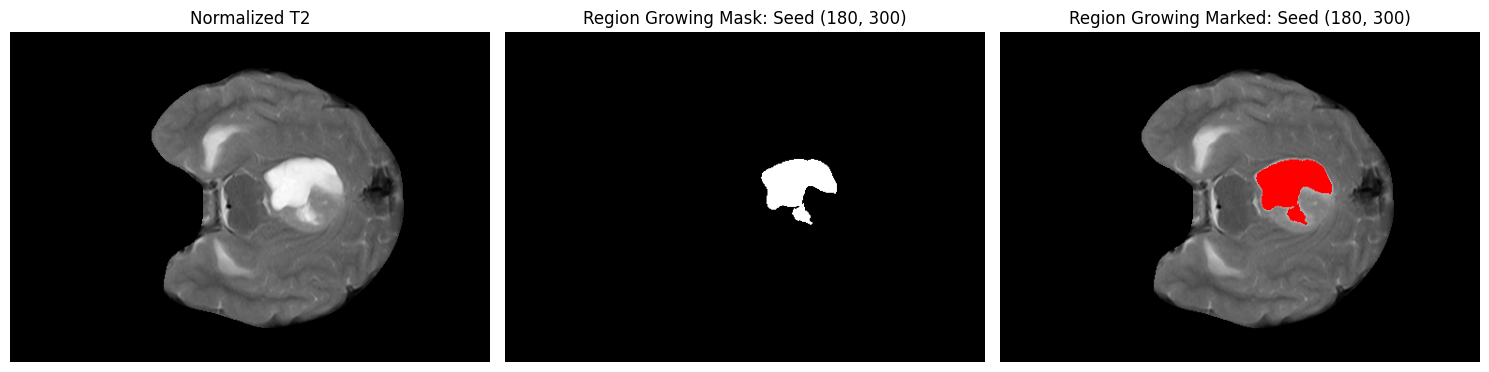

Lesion Area from Region Growing: 46225 mm^2


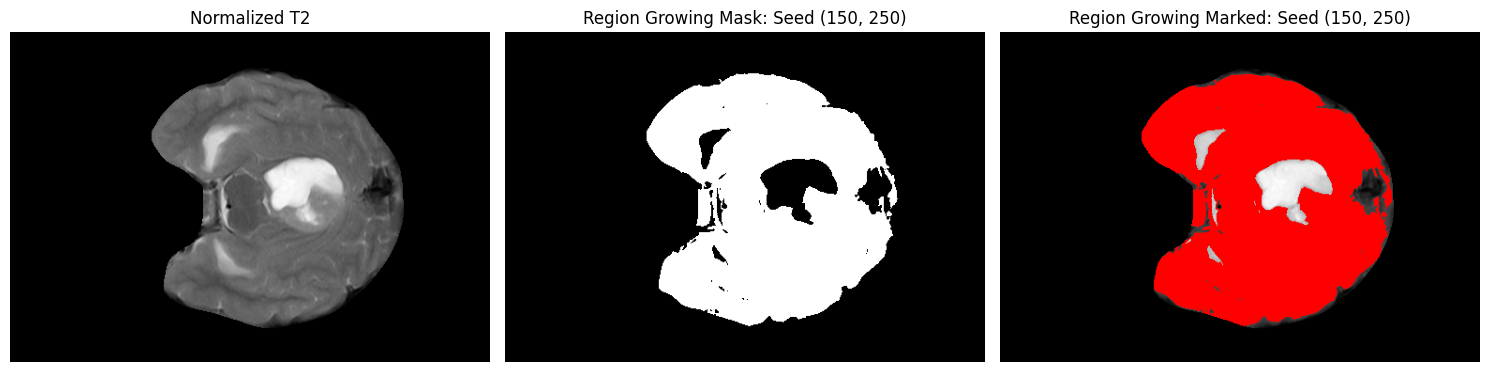

Lesion Area from Region Growing: 47143 mm^2


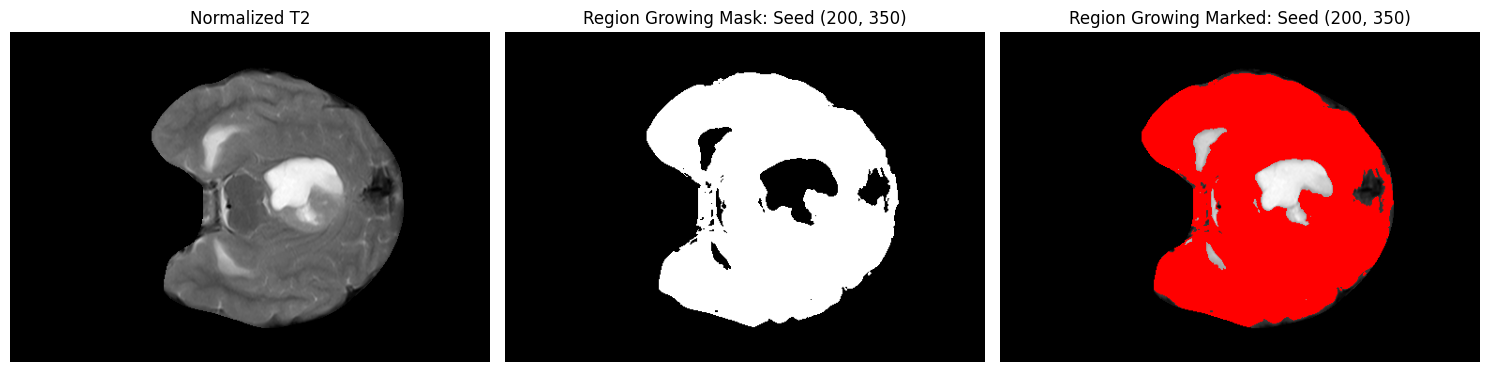

Lesion Area from Region Growing: 126941 mm^2


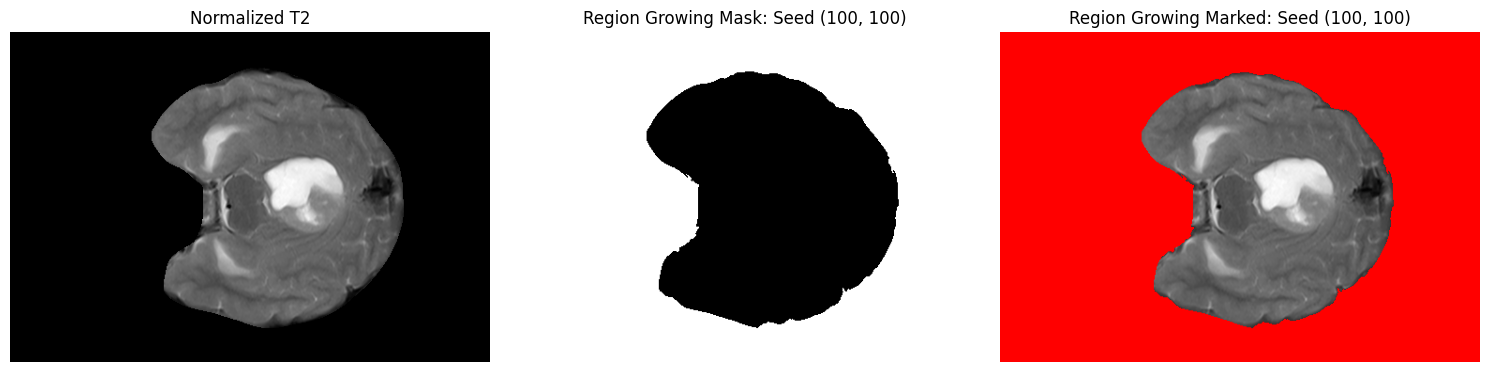

In [15]:
# parameters
seeds = [
    (180, 300),
    (150, 250),
    (200, 350),
    (100, 100)
]
tolerance = 50

# results
results = [{
    "images": [img_T2_normalized],
    "titles": ["Normalized T2"]
} for i in range(len(seeds))]

# segmentation
for i, seed in enumerate(seeds):
    segmentation_region_growing = regionGrowing(img_T2_normalized, seed, tolerance=50)
    segmentation_region_growing_marked = addMask(img_T2_normalized, segmentation_region_growing)
    results[i]["images"].append(segmentation_region_growing)
    results[i]["titles"].append(f"Region Growing Mask: Seed {seed}")
    results[i]["images"].append(segmentation_region_growing_marked)
    results[i]["titles"].append(f"Region Growing Marked: Seed {seed}")
    area_region_growing = computeLesionVolume2D(segmentation_region_growing, pixel_size=(1, 1))
    print(f"Lesion Area from Region Growing: {area_region_growing} mm^2")
    show_images_L1(
        images=results[i]["images"],
        titles=results[i]["titles"]
    )

不同的种子点会对区域生长的结果造成很大的影响，因为区域生长实际上是寻找与种子点亮度差距较小的区域。一旦种子点不在病灶区域，那么就会生长到别的地方。

#### 3.1.2 K-mean Cluster

Lesion Area from K-means: 153746 mm^2


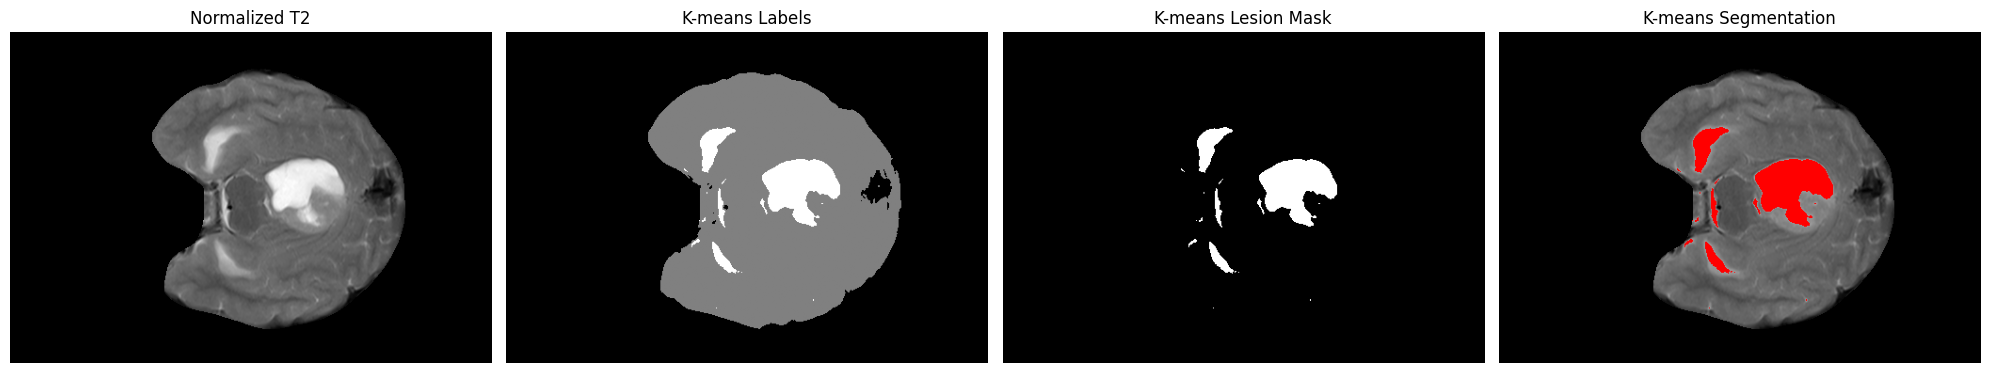

In [16]:
from sklearn.cluster import KMeans

def kmeanCluster(image, K: int = 3, spatial_weight: float = 0.9, dtype: np.dtype = np.uint8):

    # normalize
    img = normalize(image, dtype=dtype)
    h, w = img.shape
    
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    features = [img.flatten()]
    if spatial_weight > 0:
        features.append((X.flatten() * spatial_weight))
        features.append((Y.flatten() * spatial_weight))
    features = np.stack(features, axis=1)
    
    # K-means
    kmeans = KMeans(n_clusters=K, n_init=10, random_state=0)
    kmeans.fit(features)
    labels = kmeans.labels_.reshape(h, w)
    
    # generate lesion mask
    cluster_means = [img[labels==i].mean() for i in range(K)]
    lesion_label = np.argmax(cluster_means)
    mask = np.zeros_like(img, dtype=dtype)
    mask[labels==lesion_label] = 255
    
    return labels, mask

# test 
K = 3
spatial_weight = 0.05
labels, mask = kmeanCluster(img_T2, K=K, spatial_weight=spatial_weight)
segmentation_kmeans_marked = addMask(img_T2_normalized, mask)
area_kmeans = computeLesionVolume2D(segmentation_kmeans_marked, pixel_size=(1, 1))
print(f"Lesion Area from K-means: {area_kmeans} mm^2")

# show the results
show_images_L1(
    images=[img_T2_normalized, labels, mask, segmentation_kmeans_marked],
    titles=["Normalized T2", "K-means Labels", "K-means Lesion Mask", "K-means Segmentation"]
)

K-means 计算出的范围比 Region Growing 大了好多。从肉眼上看，是把多余的一大块部分也圈成了病灶。

##### Implement improved K-mean clustering

尝试在添加空间距离变换后，改变距离变换的权值。

Improved K-means parameters: {'K': 3, 'spatial_weight': 0, 'score': np.float64(209.58254764292877)}
Lesion Area from Improved K-means: 153746 mm^2


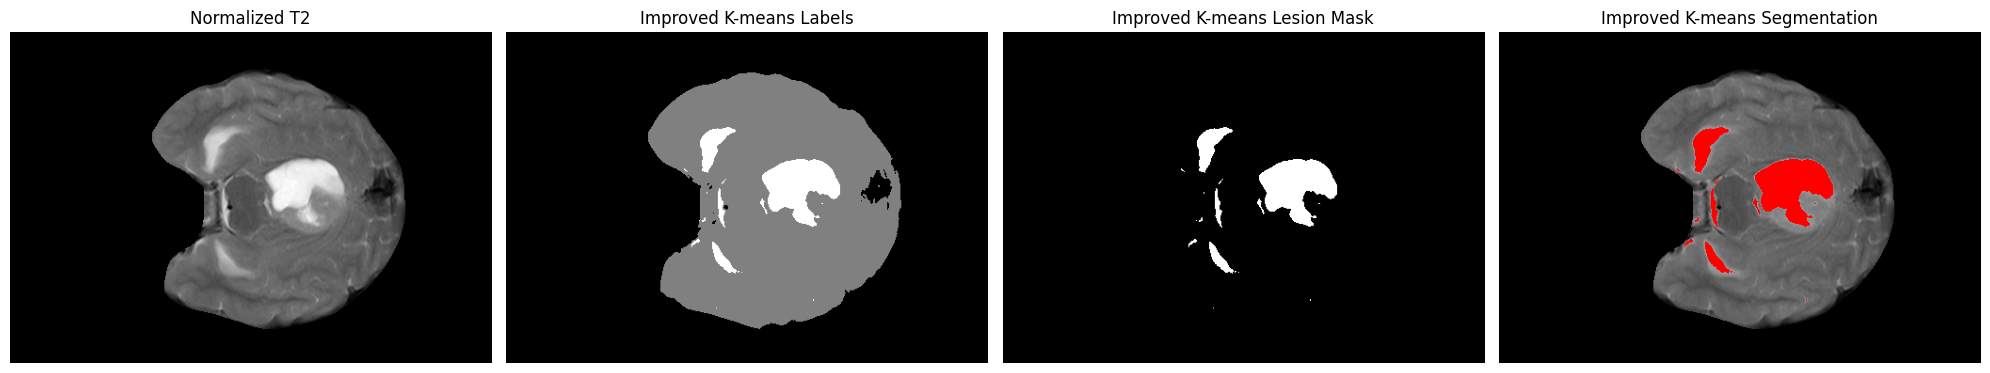

Result: K=3, Spatial Weight=0, Score=209.58


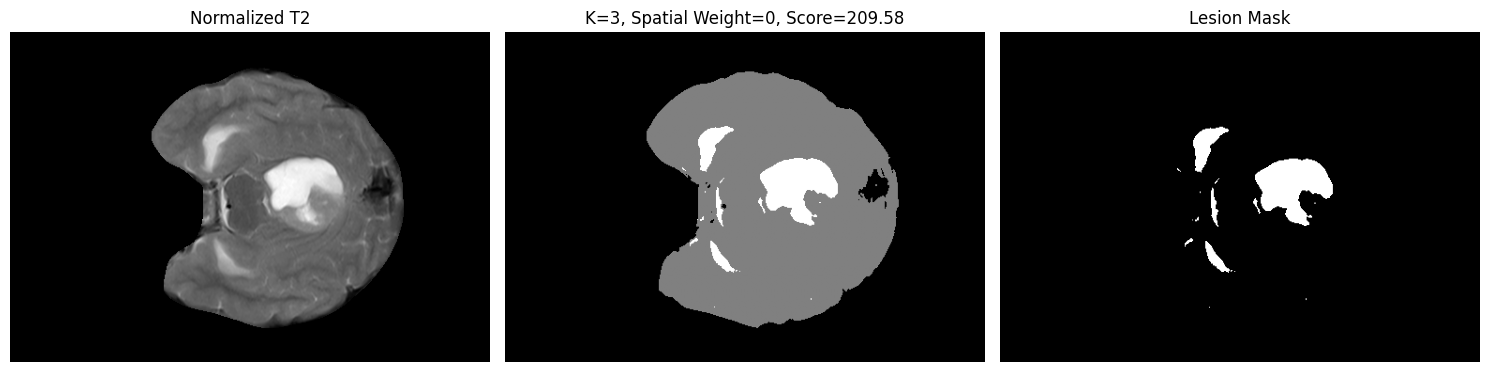

Result: K=3, Spatial Weight=0.2, Score=209.58


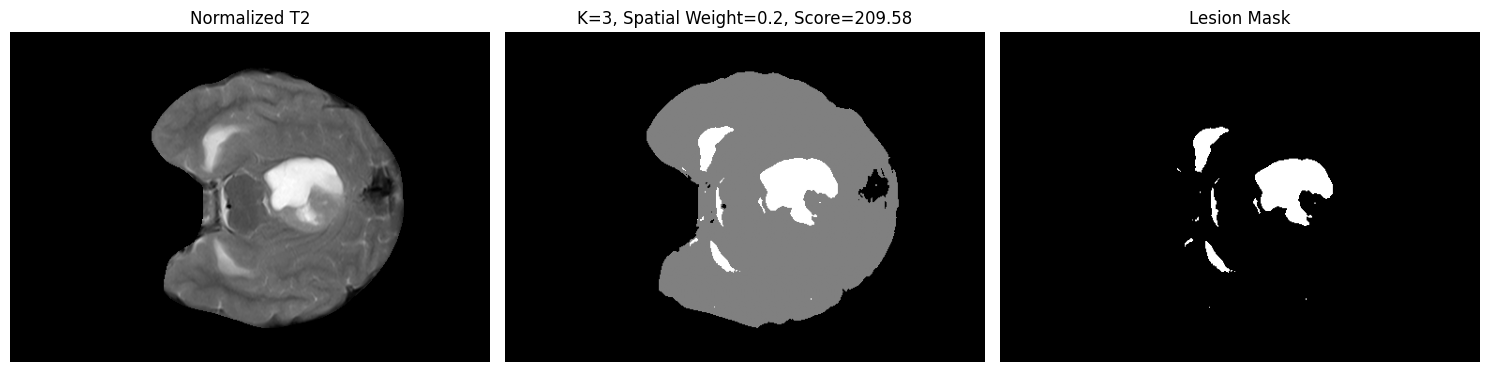

Result: K=3, Spatial Weight=1.0, Score=209.58


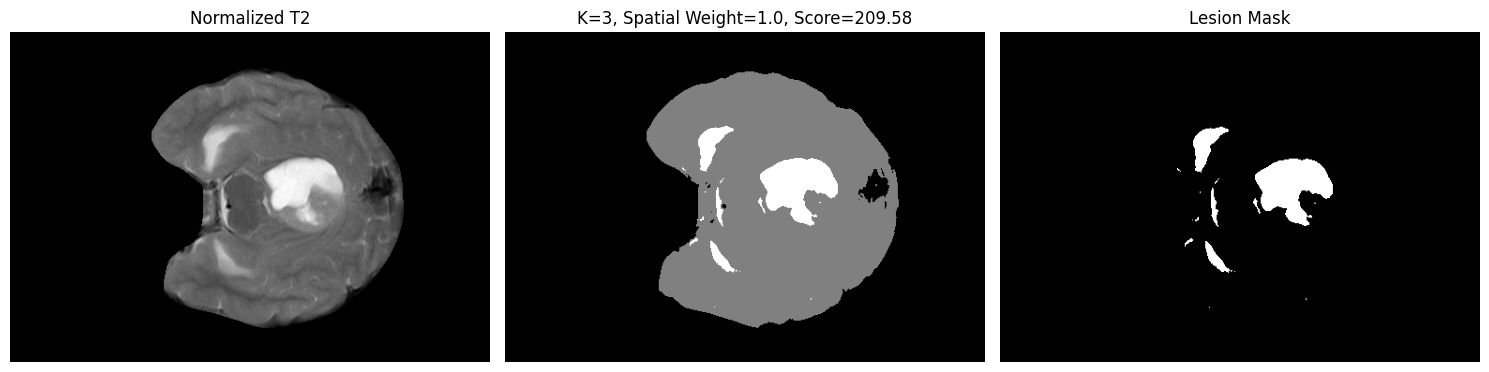

Result: K=3, Spatial Weight=2.0, Score=209.58


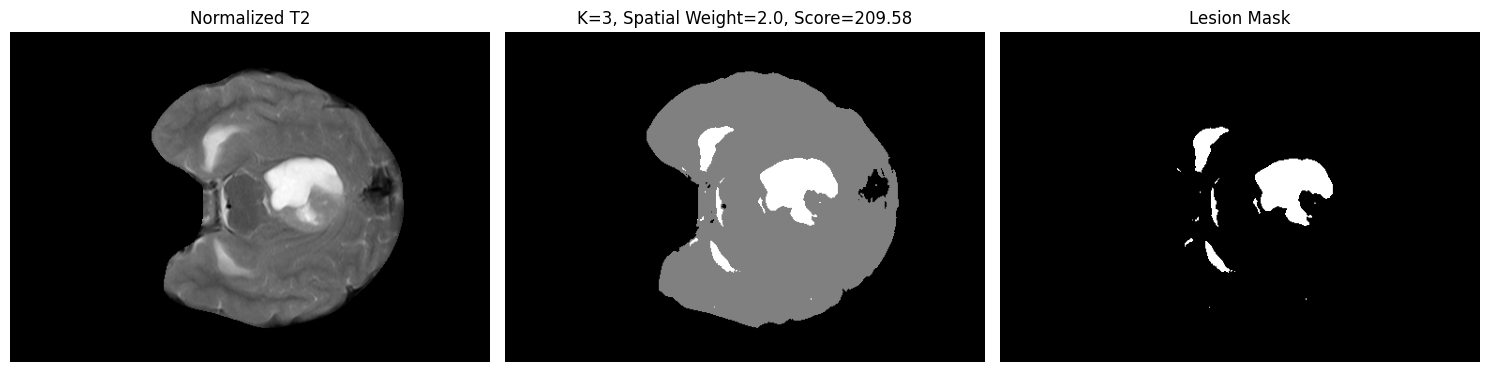

Result: K=3, Spatial Weight=10.0, Score=209.58


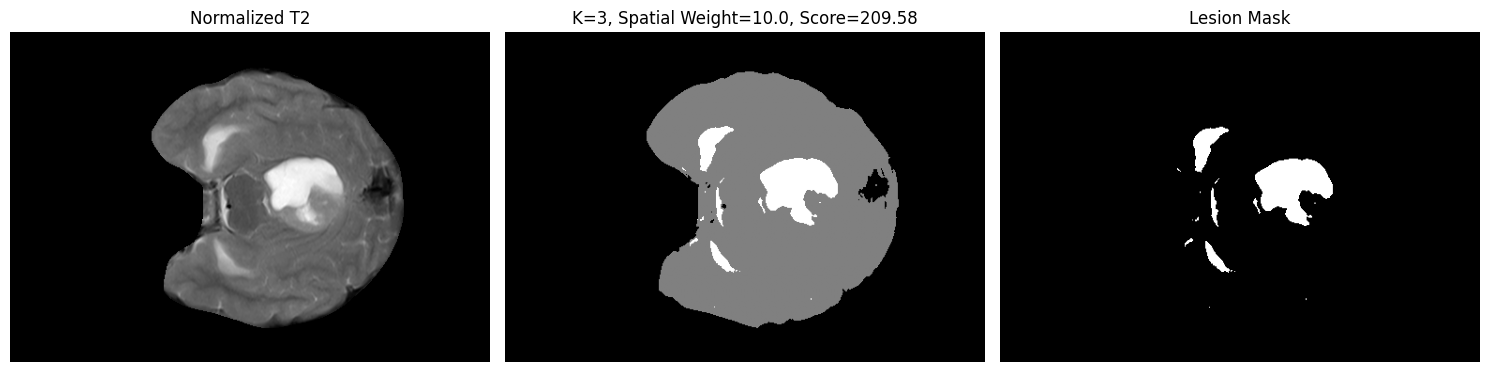

Result: K=3, Spatial Weight=200.0, Score=109.98


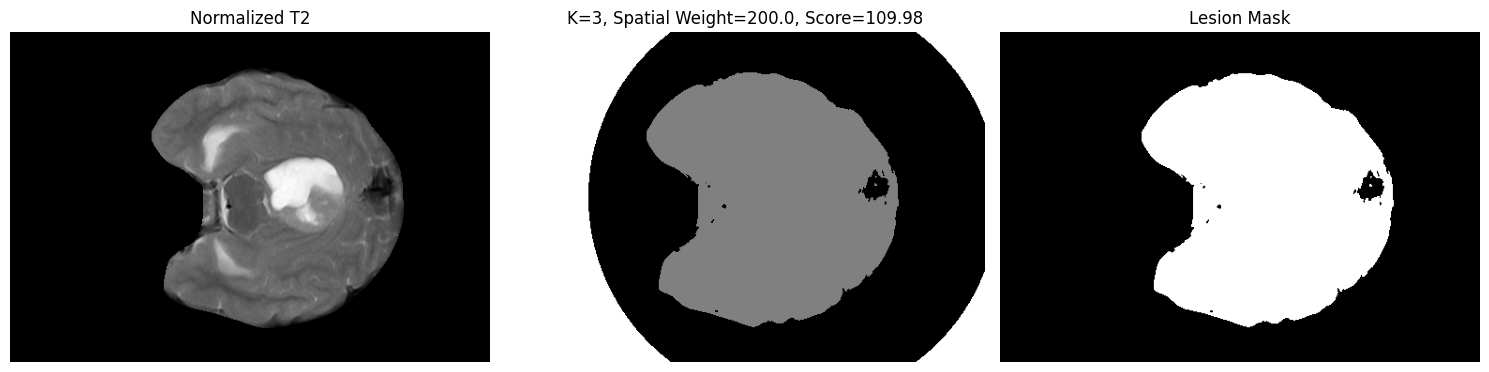

In [17]:
def improved_kmeanCluster(image, K_list: list = None, spatial_weights: list = None, dtype=np.uint8):
    """
    Improved K-means clustering with spatial weighting and multiple K values.
    
    Args:
        image: 2D numpy array, input MRI image
        K_list: list of cluster numbers to try
        spatial_weights: list of spatial_weight values to try
        dtype: output mask type
    Returns:
        best_labels: labels array of best segmentation
        best_mask: lesion mask array
        best_params: dict containing 'K' and 'spatial_weight' for best segmentation
    """
    
    img = normalize(image, dtype=dtype)
    h, w = img.shape
    cx, cy = w * 3 / 5, h / 2

    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    dist_to_center = np.sqrt((X - cx)**2 + (Y - cy)**2)
    spatial_map = 1 - dist_to_center / dist_to_center.max()
    
    best_mask = None
    best_labels = None
    best_score = -np.inf
    best_params = {}
    all_results = []
    result = {
        "labels": None,
        "mask": None,
        "params": None,
    }
    
    if K_list is None:
        K_list = [3]
    if spatial_weights is None:
        spatial_weights = [0]

    for K in K_list:
        for spatial_weight in spatial_weights:
            features = [img.flatten()]
            if spatial_weight > 0:
                features.append((spatial_map.flatten() * spatial_weight))
            features_stack = np.stack(features, axis=1)
            
            kmeans = KMeans(n_clusters=K, n_init=10, random_state=0)
            kmeans.fit(features_stack)
            labels = kmeans.labels_.reshape(h, w)
            
            cluster_means = [img[labels==i].mean() for i in range(K)]
            lesion_label = np.argmax(cluster_means)
            mask = np.zeros_like(img, dtype=dtype)
            mask[labels==lesion_label] = 255
            
            score = img[mask==255].mean()
            if score > best_score:
                best_score = score
                best_mask = mask
                best_labels = labels
                best_params = {'K': K, 'spatial_weight': spatial_weight, 'score': score}

            result = {
                "labels": labels,
                "mask": mask,
                "params": {'K': K, 'spatial_weight': spatial_weight, 'score': score}
            }
            all_results.append(result)
    
    return best_labels, best_mask, best_params, all_results


# test
# only change the spatial_weight
labels_imp, mask_imp, params, all_results = improved_kmeanCluster(
    img_T2, 
    K_list=[3],
    spatial_weights=[0, 0.2, 1.0, 2.0, 10.0, 200.0]
)

segmentation_imp_marked = addMask(img_T2_normalized, mask_imp)
area_imp = computeLesionVolume2D(segmentation_imp_marked, pixel_size=(1, 1))

print(f"Improved K-means parameters: {params}")
print(f"Lesion Area from Improved K-means: {area_imp} mm^2")

# show the images
show_images_L1(
    images=[img_T2_normalized, labels_imp, mask_imp, segmentation_imp_marked],
    titles=["Normalized T2", "Improved K-means Labels", "Improved K-means Lesion Mask", "Improved K-means Segmentation"]
)

for result in all_results:
    print(f"Result: K={result['params']['K']}, Spatial Weight={result['params']['spatial_weight']}, Score={result['params']['score']:.2f}")
    show_images_L1(
        images=[img_T2_normalized, result["labels"], result["mask"]],
        titles=[
            "Normalized T2", 
            f"K={result['params']['K']}, Spatial Weight={result['params']['spatial_weight']}, Score={result['params']['score']:.2f}", 
            "Lesion Mask"
        ]
    )

附加距离变换，并修改距离变换权值，对结果有优化，但是优化不明显。尝试修改 K。

Improved K-means parameters: {'K': 7, 'spatial_weight': 0, 'score': np.float64(235.76622843056697)}
Lesion Area from Improved K-means: 158848 mm^2


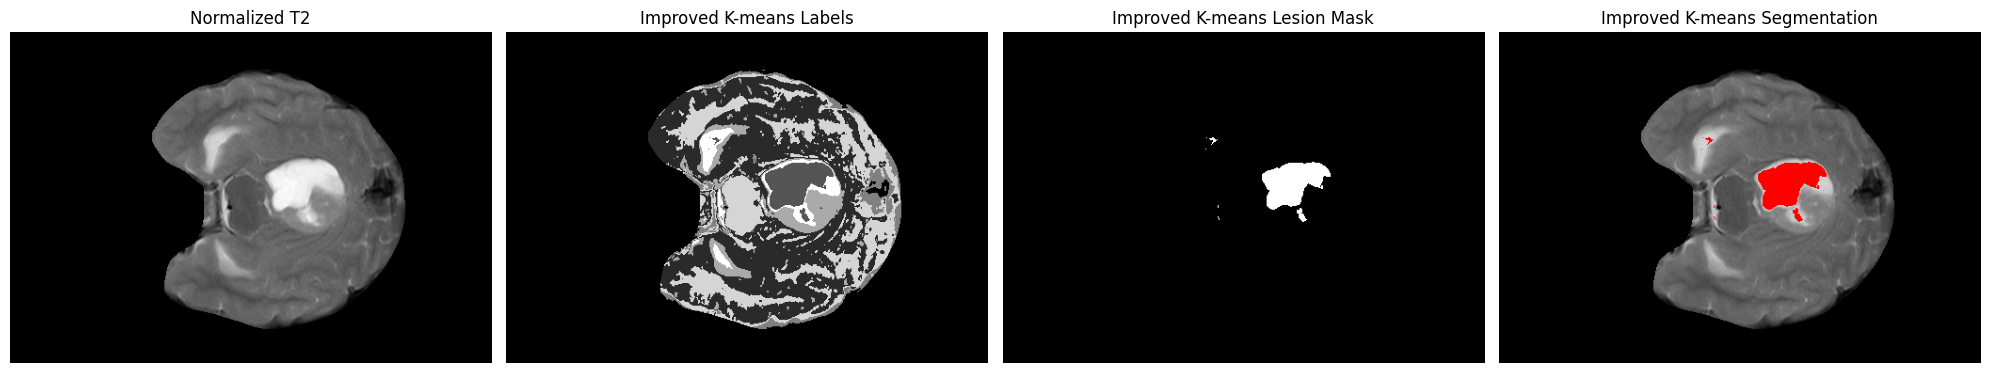

Result: K=3, Spatial Weight=0, Score=209.58


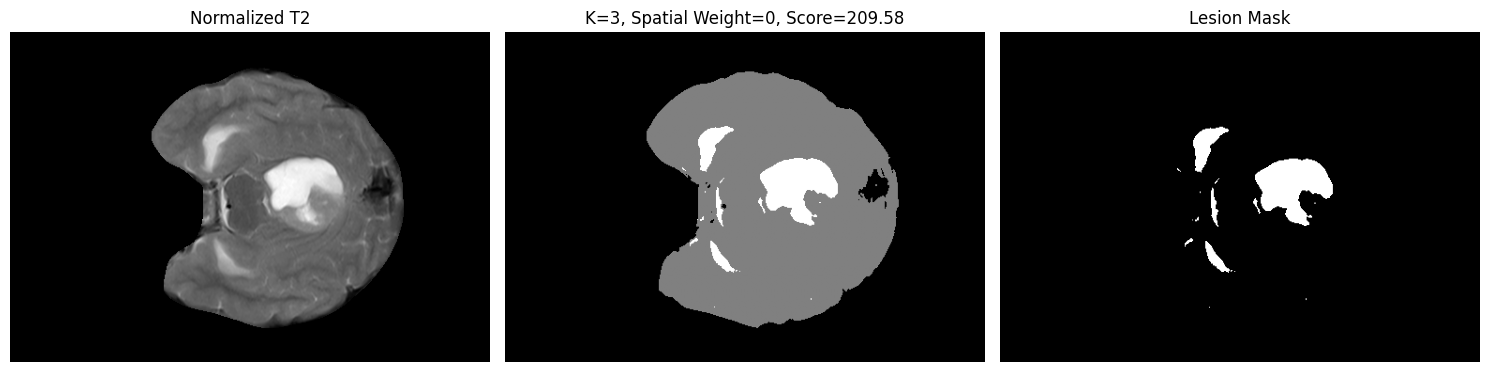

Result: K=4, Spatial Weight=0, Score=214.46


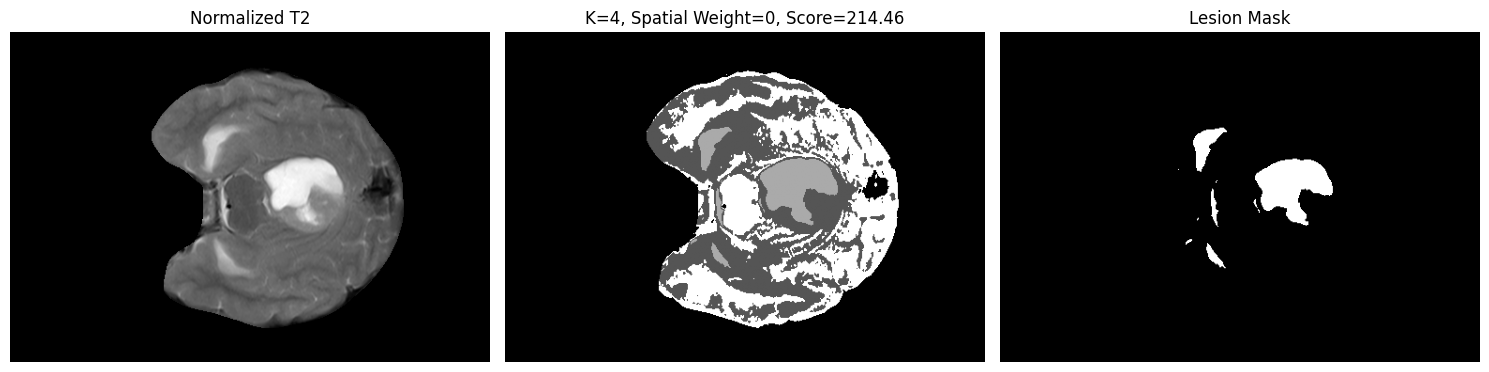

Result: K=5, Spatial Weight=0, Score=223.54


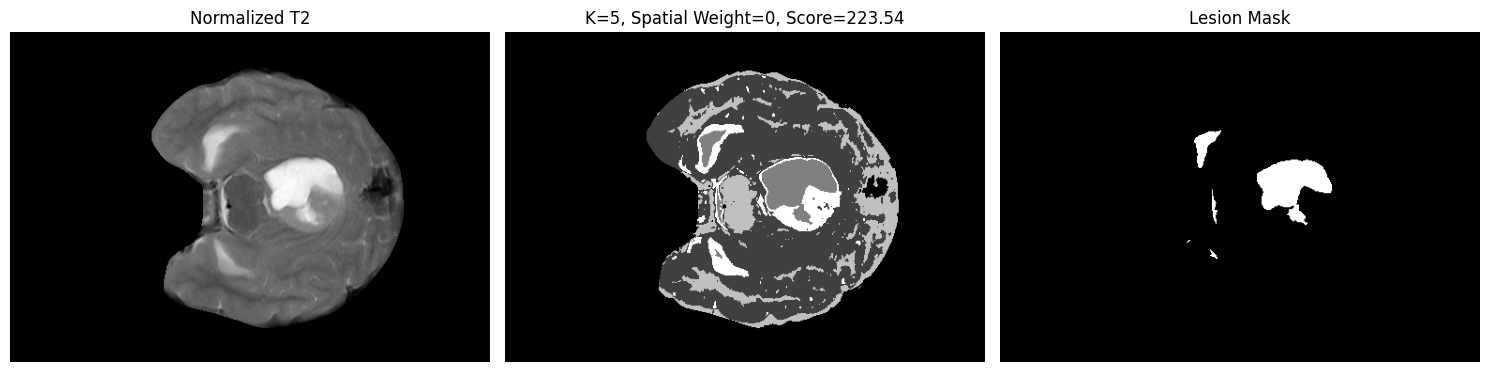

Result: K=6, Spatial Weight=0, Score=224.56


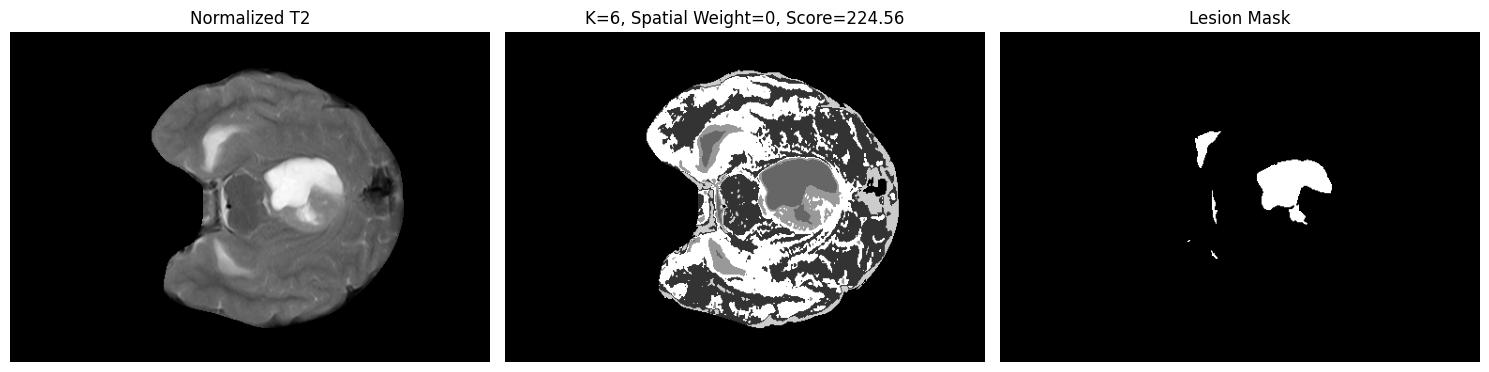

Result: K=7, Spatial Weight=0, Score=235.77


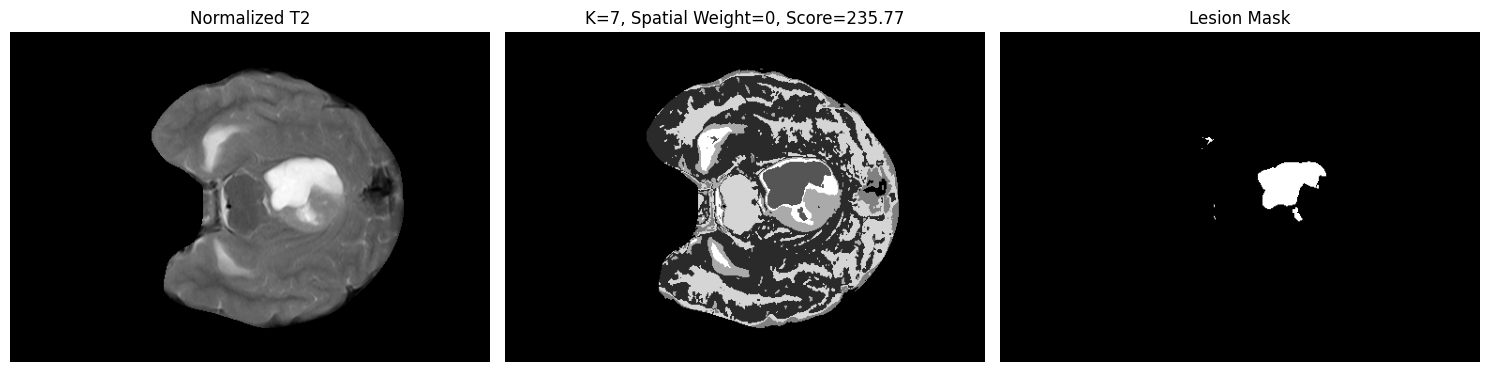

In [18]:
# test
# only change the spatial_weight
labels_imp, mask_imp, params, all_results = improved_kmeanCluster(
    img_T2, 
    K_list=range(3, 8),
    spatial_weights=[0]
)

segmentation_imp_marked = addMask(img_T2_normalized, mask_imp)
area_imp = computeLesionVolume2D(segmentation_imp_marked, pixel_size=(1, 1))

print(f"Improved K-means parameters: {params}")
print(f"Lesion Area from Improved K-means: {area_imp} mm^2")

# show the images
show_images_L1(
    images=[img_T2_normalized, labels_imp, mask_imp, segmentation_imp_marked],
    titles=["Normalized T2", "Improved K-means Labels", "Improved K-means Lesion Mask", "Improved K-means Segmentation"]
)

for result in all_results:
    print(f"Result: K={result['params']['K']}, Spatial Weight={result['params']['spatial_weight']}, Score={result['params']['score']:.2f}")
    show_images_L1(
        images=[img_T2_normalized, result["labels"], result["mask"]],
        titles=[
            "Normalized T2", 
            f"K={result['params']['K']}, Spatial Weight={result['params']['spatial_weight']}, Score={result['params']['score']:.2f}", 
            "Lesion Mask"
        ]
    )

改变 K 对效果的提升还是很明显的。但是就像老师理论课上说的一样，K 太大之后对每个层的具体含义就显得很乱，虽然结果有所优化，但是在医学上是不合理的。

选出一个最优解。

Improved K-means parameters: {'K': 12, 'spatial_weight': 1.0, 'score': np.float64(238.70964660936008)}
Lesion Area from Improved K-means: 2094 mm^2


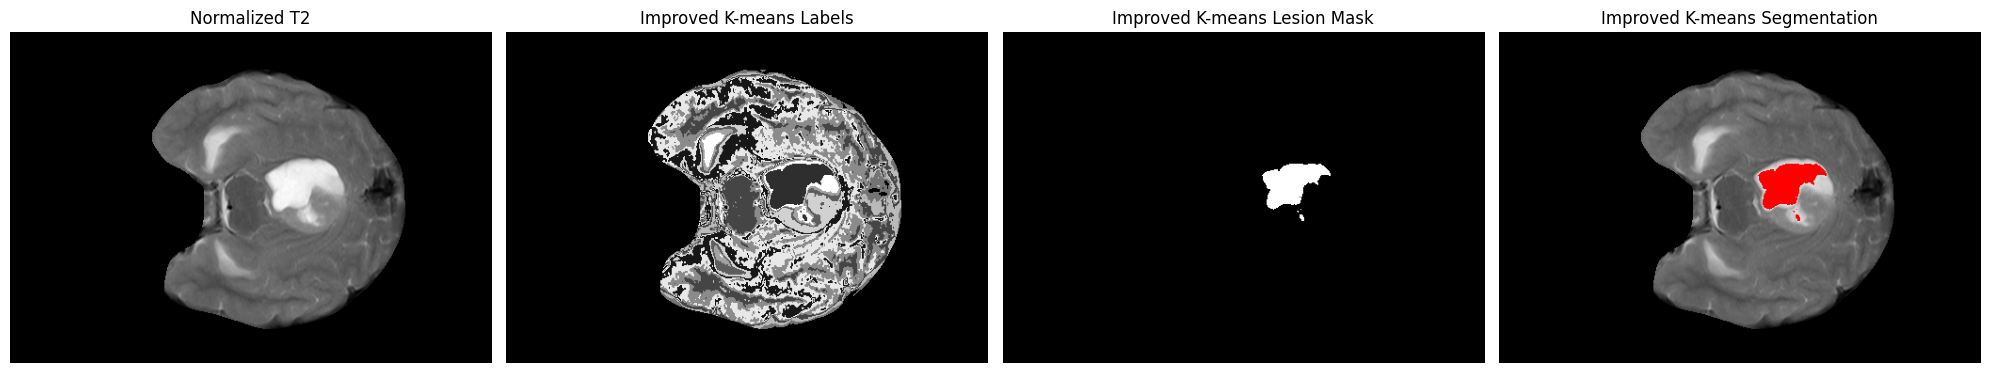

In [19]:
# test
# only change the spatial_weight
labels_imp, mask_imp, params, all_results = improved_kmeanCluster(
    img_T2, 
    K_list=range(3, 13),
    spatial_weights=[0, 0.2, 1.0, 2.0, 10.0, 200.0]
)

segmentation_imp_marked = addMask(img_T2_normalized, mask_imp)
area_imp = computeLesionVolume2D(mask_imp, pixel_size=(1, 1))

print(f"Improved K-means parameters: {params}")
print(f"Lesion Area from Improved K-means: {area_imp} mm^2")

# show the images
show_images_L1(
    images=[img_T2_normalized, labels_imp, mask_imp, segmentation_imp_marked],
    titles=["Normalized T2", "Improved K-means Labels", "Improved K-means Lesion Mask", "Improved K-means Segmentation"]
)

#### Watershed Segmentation

Lesion Area from Watershed: 3202 mm^2


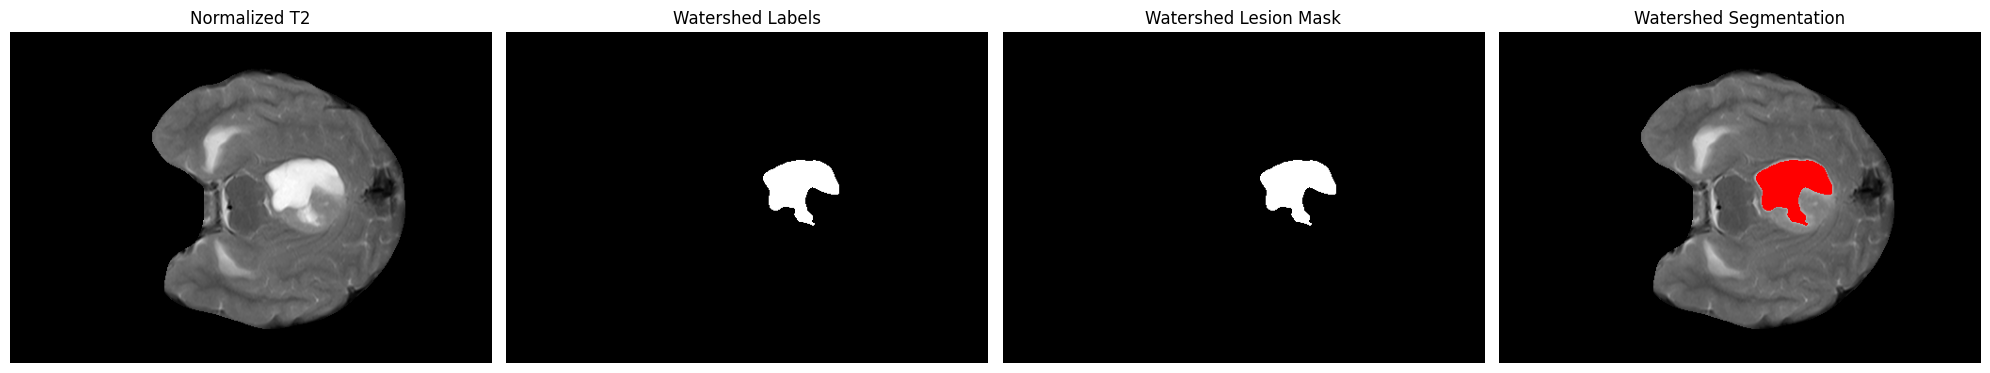

In [20]:
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage as ndi

def watershedSegmentation(image, threshold_ratio: float = 0.7, min_distance: int = 100, dtype=np.uint8):
    """
    Watershed-based segmentation for lesion region.
    Compatible with modern scikit-image versions (>=0.20+)
    """
    img = normalize(image, dtype=dtype)
    img_smooth = cv2.GaussianBlur(img, (5,5), 0)

    thresh_val = threshold_ratio * img_smooth.max()
    ret, binary = cv2.threshold(img_smooth, thresh_val, 255, cv2.THRESH_BINARY)
    binary = binary.astype(np.uint8)

    distance = ndi.distance_transform_edt(binary)

    coordinates = peak_local_max(distance, min_distance=min_distance, labels=binary)
    markers = np.zeros_like(img, dtype=np.int32)
    for i, (r, c) in enumerate(coordinates, start=1):
        markers[r, c] = i

    labels = watershed(-distance, markers, mask=binary)
    mask = np.zeros_like(img, dtype=dtype)
    mask[labels > 0] = 255

    return labels, mask


# test
labels_ws, mask_ws = watershedSegmentation(img_T2, threshold_ratio=0.7, min_distance=100)
segmentation_ws_marked = addMask(img_T2_normalized, mask_ws)
area_ws = computeLesionVolume2D(mask_ws, pixel_size=(1,1))
print(f"Lesion Area from Watershed: {area_ws} mm^2")

# show the images
show_images_L1(
    images=[img_T2_normalized, labels_ws, mask_ws, segmentation_ws_marked],
    titles=["Normalized T2", "Watershed Labels", "Watershed Lesion Mask", "Watershed Segmentation"]
)

尝试不同的参数：
- 阈值 `threshold_ratio`
- 距离变换 `min_distance`

========== Results for varying threshold_ratio ==========

Result: Threshold Ratio=0.5, Area=5138.00 mm^2


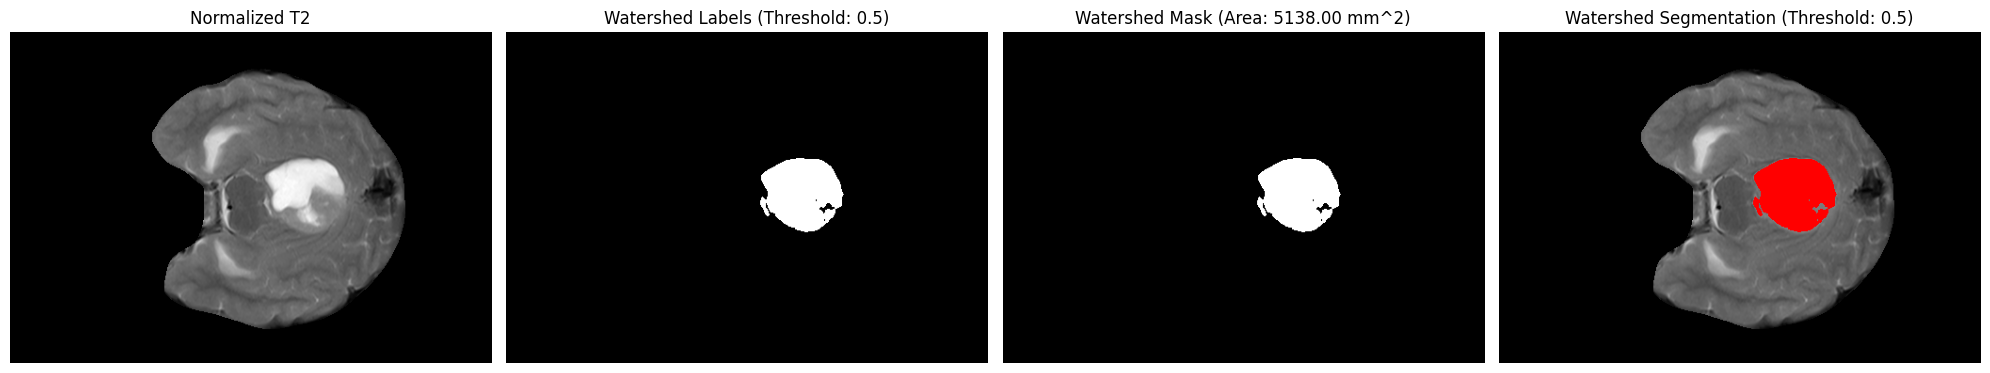

Result: Threshold Ratio=0.6, Area=3635.00 mm^2


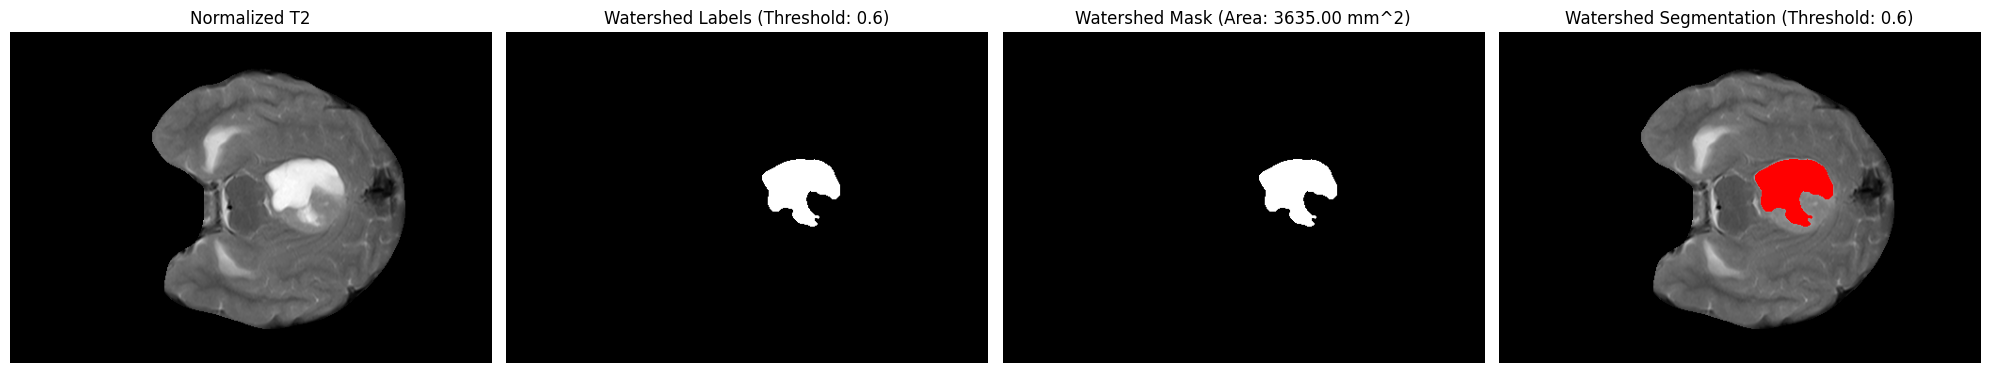

Result: Threshold Ratio=0.7, Area=3202.00 mm^2


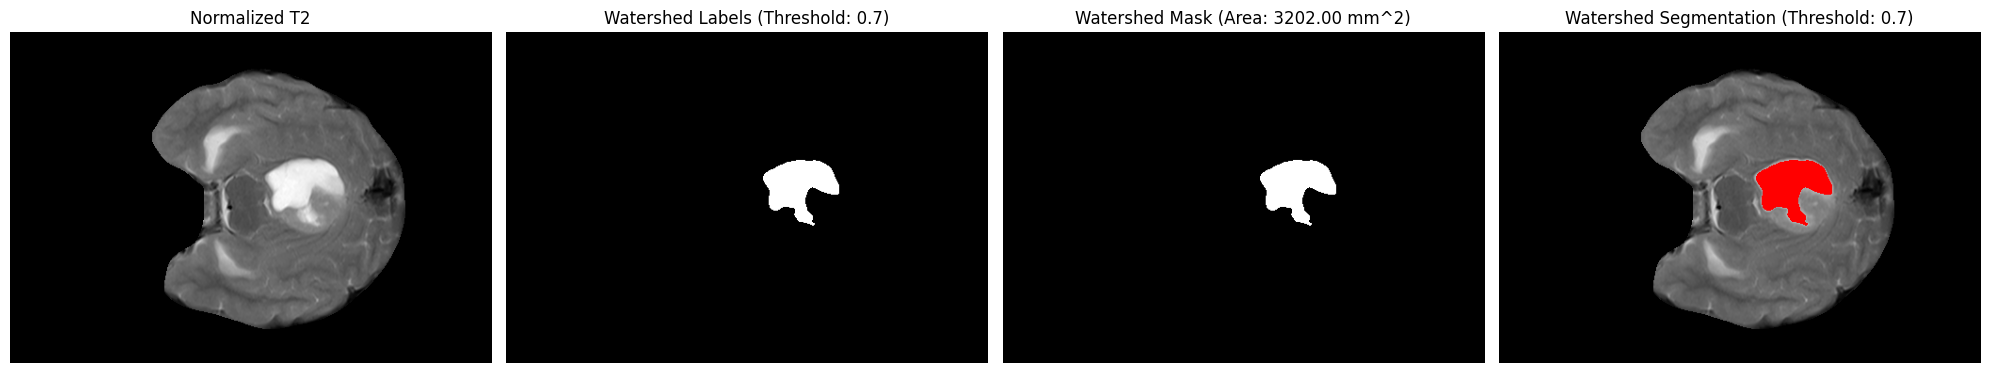

Result: Threshold Ratio=0.8, Area=2564.00 mm^2


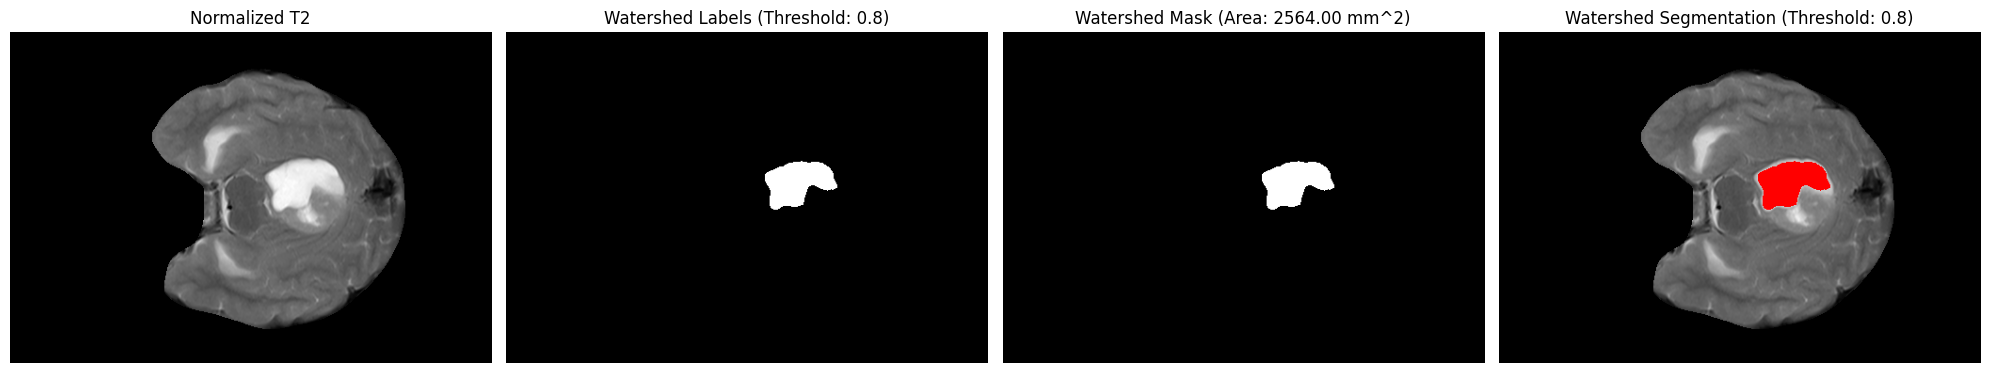

Result: Threshold Ratio=0.9, Area=1895.00 mm^2


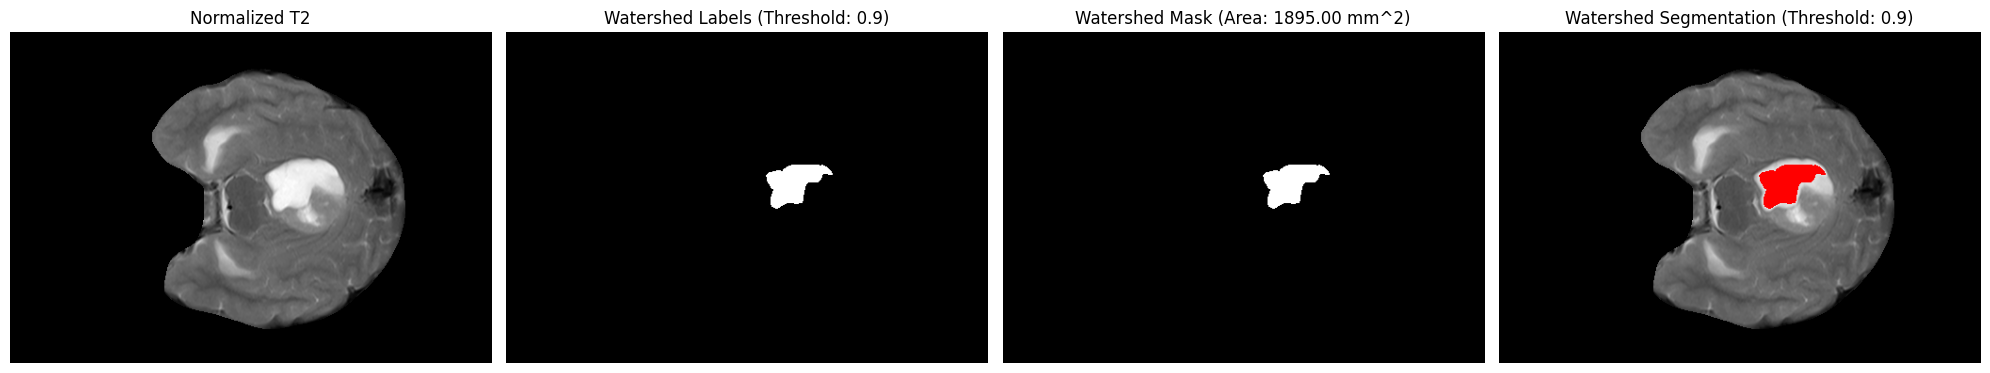

========== Results for varying min_distance ==========

Result: Min Distance=20, Area=3935.00 mm^2


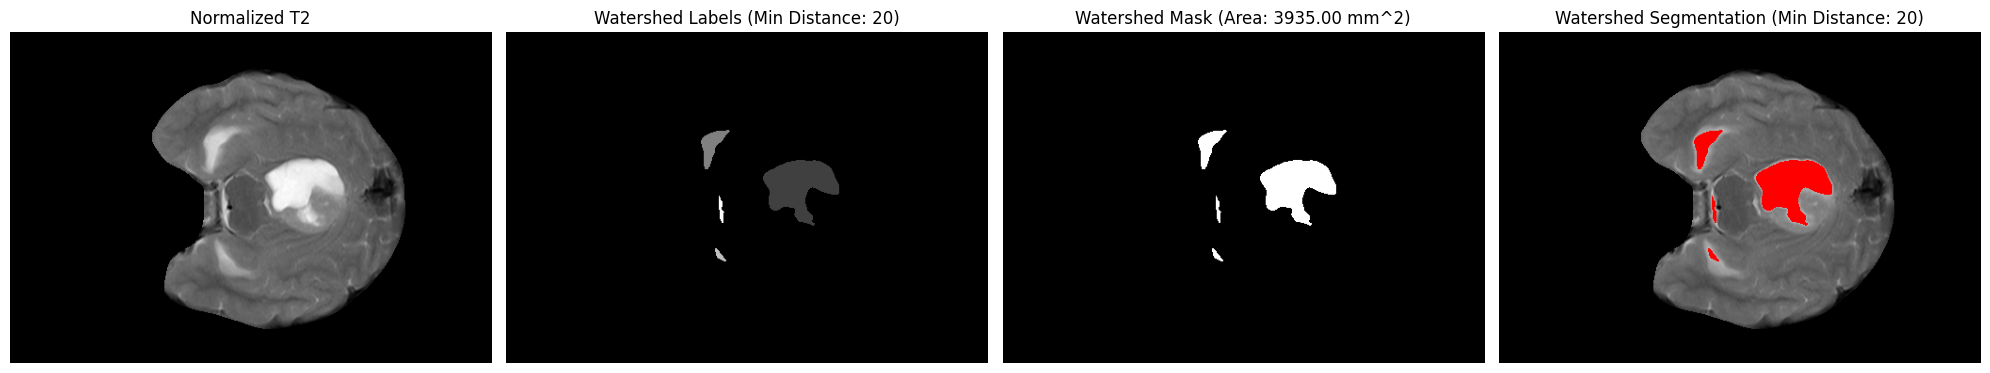

Result: Min Distance=50, Area=3841.00 mm^2


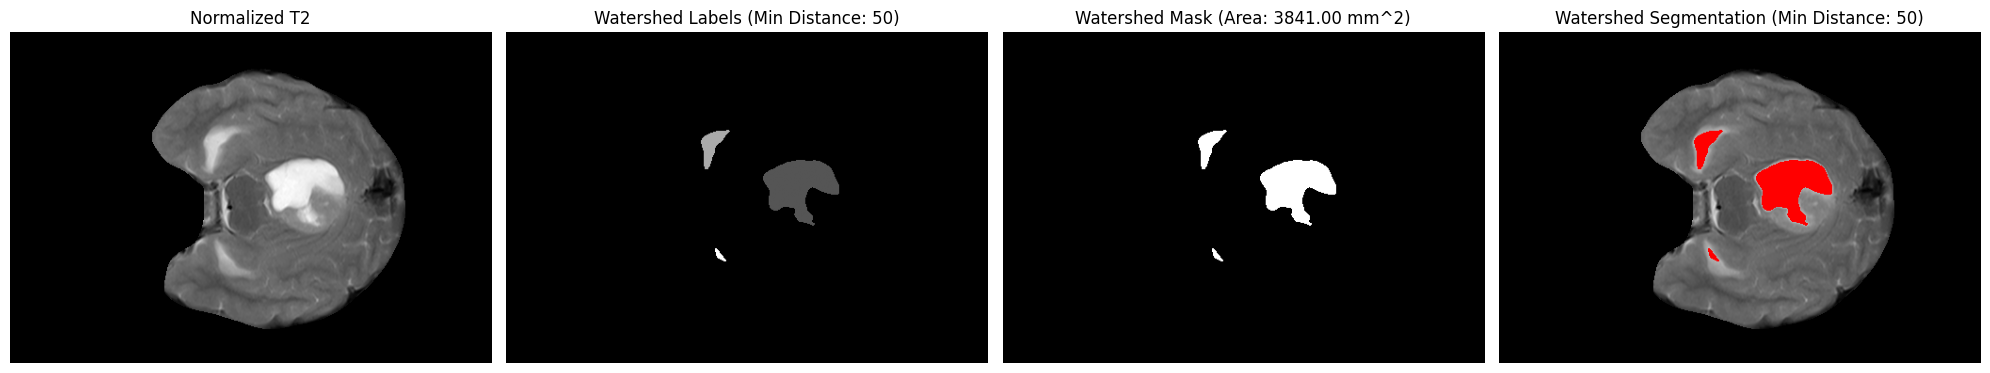

Result: Min Distance=100, Area=3202.00 mm^2


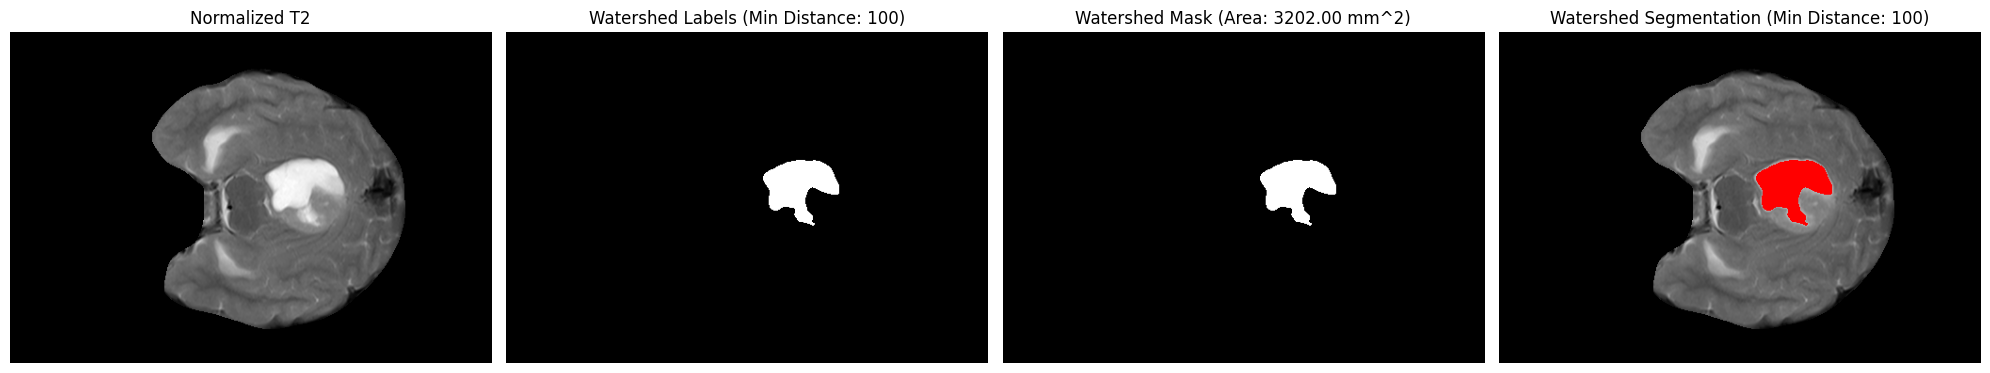

Result: Min Distance=200, Area=0.00 mm^2


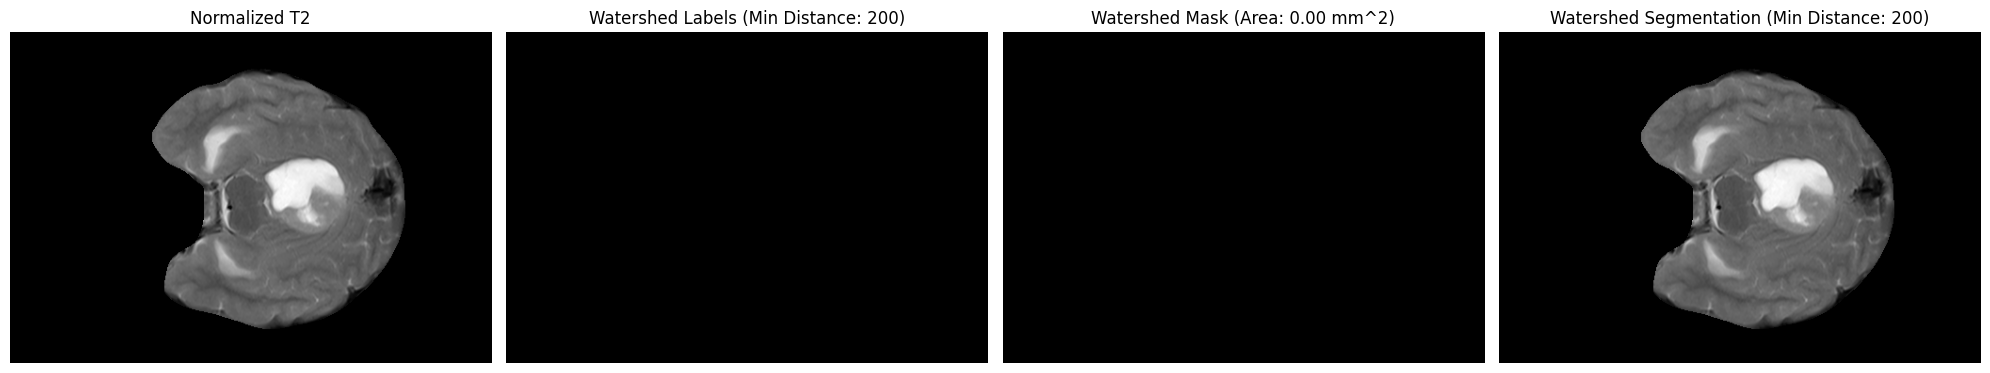

In [21]:
# test
threshold_ratio_list = [0.5, 0.6, 0.7, 0.8, 0.9]
results_threshold = []
min_distance_list = [20, 50, 100, 200]
results_distance = []

for threshold_ratio in threshold_ratio_list:
    labels_ws, mask_ws = watershedSegmentation(img_T2, threshold_ratio=threshold_ratio)
    segmentation_ws_marked = addMask(img_T2_normalized, mask_ws)
    area_ws = computeLesionVolume2D(mask_ws, pixel_size=(1,1))
    result_threshold = {}
    result_threshold["threshold_ratio"] = threshold_ratio
    result_threshold["labels"] = labels_ws
    result_threshold["masks"] = mask_ws
    result_threshold["areas"] = area_ws
    result_threshold["images"] = segmentation_ws_marked
    result_threshold["titles"] = f"Threshold: {threshold_ratio}"
    results_threshold.append(result_threshold)


for min_distance in min_distance_list:
    labels_ws, mask_ws = watershedSegmentation(img_T2, min_distance=min_distance)
    segmentation_ws_marked = addMask(img_T2_normalized, mask_ws)
    area_ws = computeLesionVolume2D(mask_ws, pixel_size=(1,1))
    result_distance = {}
    result_distance["min_distance"] = min_distance
    result_distance["labels"] = labels_ws
    result_distance["masks"] = mask_ws
    result_distance["areas"] = area_ws
    result_distance["images"] = segmentation_ws_marked
    result_distance["titles"] = f"Min Distance: {min_distance}"
    results_distance.append(result_distance)

# show the images
print("========== Results for varying threshold_ratio ==========\n")
for result in results_threshold:
    print(f"Result: Threshold Ratio={result['threshold_ratio']}, Area={result['areas']:.2f} mm^2")
    show_images_L1(
        images=[img_T2_normalized, result["labels"], result["masks"], result["images"]],
        titles=[
            "Normalized T2", 
            f"Watershed Labels (Threshold: {result['threshold_ratio']})", 
            f"Watershed Mask (Area: {result['areas']:.2f} mm^2)", 
            f"Watershed Segmentation (Threshold: {result['threshold_ratio']})"
        ]
    )

print("========== Results for varying min_distance ==========\n")
for result in results_distance:
    print(f"Result: Min Distance={result['min_distance']}, Area={result['areas']:.2f} mm^2")
    show_images_L1(
        images=[img_T2_normalized, result["labels"], result["masks"], result["images"]],
        titles=[
            "Normalized T2", 
            f"Watershed Labels (Min Distance: {result['min_distance']})", 
            f"Watershed Mask (Area: {result['areas']:.2f} mm^2)", 
            f"Watershed Segmentation (Min Distance: {result['min_distance']})"
        ]
    )


效果还是很明显的。增大阈值之后，锁定的范围明显在减少；添加了距离变换之后，图像中最后锁定的对象数量明显减少了，让一些边缘部分的散点都去除干净了。

最后选取一个个人认为最优的参数。

Lesion Area from Watershed: 3202 mm^2
Watershed Segmentation with Threshold Ratio=0.7 and Min Distance=100


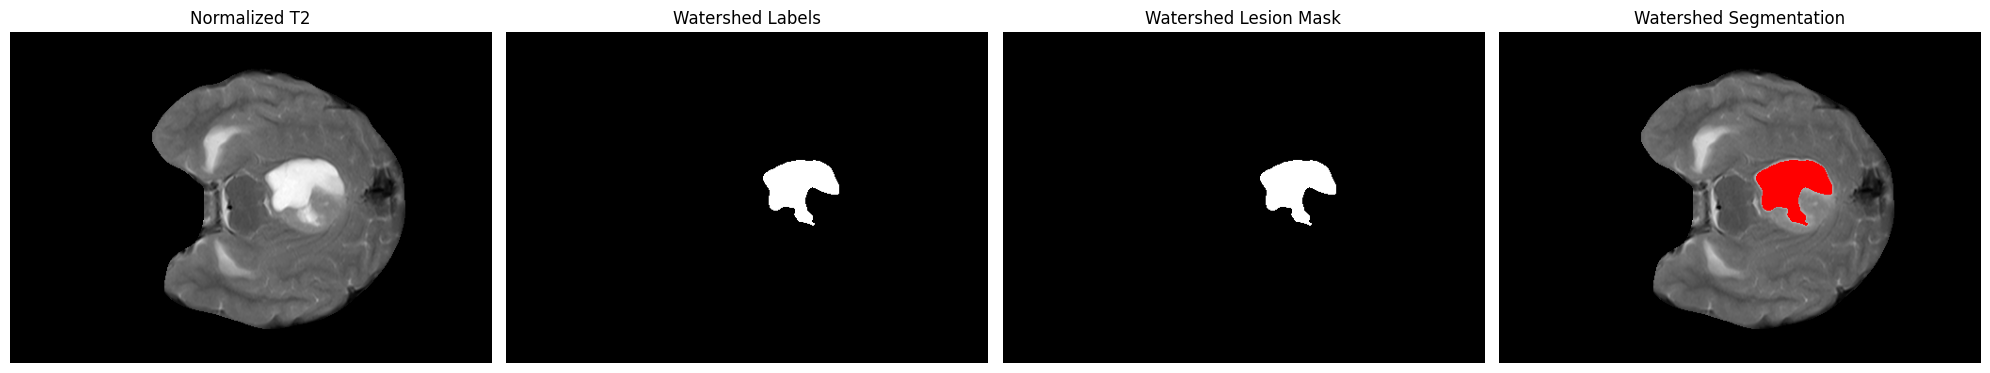

In [22]:
# test
threshold_ratio = 0.7
min_distance = 100
labels_ws, mask_ws = watershedSegmentation(img_T2, threshold_ratio=threshold_ratio, min_distance=min_distance)
segmentation_ws_marked = addMask(img_T2_normalized, mask_ws)
area_ws = computeLesionVolume2D(mask_ws, pixel_size=(1,1))
print(f"Lesion Area from Watershed: {area_ws} mm^2")

# show the images
print(f"Watershed Segmentation with Threshold Ratio={threshold_ratio} and Min Distance={min_distance}")
show_images_L1(
    images=[img_T2_normalized, labels_ws, mask_ws, segmentation_ws_marked],
    titles=["Normalized T2", "Watershed Labels", "Watershed Lesion Mask", "Watershed Segmentation"]
)